---

## **I Trained an AI on Its Own Output — Here's What It Forgot**
### **Model Collapse in AI: A Wine Quality Experiment**

---

| | |
|---|---|
| **Submitted By :** | Sindhu Marupaka |
| **Batch :** | PGA56 |
| **Course :** | Postgraduate Program in Data Science and Analytics with GenAI |
| **Institution :** | Imarticus Learning |
| **Competition :** | Imarticus Data Science Blogathon  |
| **Tools Used :** | Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Google Colab |

---

## **1. Introduction**

AI models are increasingly trained on data that other AI models generated — not just real, human-created data. This raises a simple but important question: if a model keeps learning from its own output, generation after generation, does it slowly start to forget what real data actually looks like?

This project investigates that question directly. Using the real UCI Wine Quality dataset, I built a small experiment where a model is trained on real data once, then repeatedly trained on synthetic data generated by the previous version of itself — across five generations. At every step, I measure how close the model's understanding of "real" wine data stays to the truth.

## **2. Problem Statement**

As more AI-generated content spreads across the internet, future AI models risk being trained on synthetic data without anyone realizing it. If this happens repeatedly, models could gradually lose accuracy, diversity, and understanding of real-world patterns — a phenomenon known as **model collapse**.

This project asks: **does training a model recursively on its own synthetic output cause measurable degradation, and if so, what exactly gets lost first?**

## **3. Objectives**

- Build a real, working simulation of model collapse using a real-world dataset
- Generate synthetic data using a class-conditional Gaussian Mixture Model (GMM), so every synthetic sample has a defensible, known label
- Train a classifier on each generation's data and test it against the same real, untouched test set every time
- Track multiple signals of change across generations — not just accuracy, but also feature distribution drift, correlation changes, and diversity within each class
- Determine whether the model forgets entire categories of wine, or something more subtle: the variation *within* each category

## **4. Dataset Description**

This project uses the **UCI Wine Quality (Red Wine)** dataset, a real, publicly available dataset from Cortez et al. (2009).

- **Samples:** 1,599 raw records; after removing 240 exact duplicate rows (see dataset audit), 1,359 unique real red wine records were used for the experiment. The final training set (after the 80/20 split) contains 1,087 records: 890 Medium, 147 High, and 50 Low quality.
- **Features:** 11 physicochemical measurements (fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol)
- **Target:** Quality score, originally rated 3–8 by wine tasters. For this project, quality scores are grouped into three simpler categories — **Low (3–4), Medium (5–6), High (7–8)** — to keep the classification task meaningful and workable for synthetic generation.

## **5. Scope of Analysis**

**This project covers:**

- A full audit of the real dataset (structure, missing values, duplicates, class balance, feature distributions, correlations, and outliers)
- A one-time, permanent split of the data into training data and a held-out real test set that is never touched again
- Design and locking of the synthetic data generation method (class-conditional GMM, with model complexity chosen using BIC/AIC)
- Five generations of recursive synthetic training (Gen 1 through Gen 5), each trained only on the previous generation's synthetic output
- Evaluation of every generation's classifier against the same real test set, using multiple measures: accuracy, F1-score, feature distribution drift, correlation changes, and within-class diversity
- A final, evidence-based conclusion about what, if anything, the AI "forgot" — without assuming the result in advance.



## Section 1: Setup & Load the Dataset

In [1]:

import pandas as pd
import numpy as np

In [2]:
# This is the web address where the real wine data lives
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/red-wine-quality/winequality-red.csv"

# pandas.read_csv() downloads the file from that address
# and turns it into a table we can work with, called a "DataFrame"
wine_data = pd.read_csv(url)

# Let's print a simple confirmation message
print("Data loaded successfully!")

Data loaded successfully!


In [3]:
# .head() shows us the first 5 rows of the table
# This is just so we can SEE what the data actually looks like
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# .shape tells us (number of rows, number of columns)
print("Shape of the dataset:", wine_data.shape)

Shape of the dataset: (1599, 12)


In [5]:
# .columns gives us the list of every column name in the dataset
print("Column names:")
print(wine_data.columns.tolist())

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [6]:
# .info() gives us a summary: column names, how many non-missing values each has,
# and what data type each column is (numbers, text, etc.)
wine_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## Section 2: Dataset Audit — Structure, Missing Values, Duplicates & Class Balance

### **Confirm there are no missing values**

In [7]:
# .isnull() checks every single cell: is it empty (missing) or not?
# .sum() then adds up how many missing values exist, PER COLUMN
missing_values = wine_data.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### **Count duplicate rows**

In [8]:
# .duplicated() checks each row: does an identical row appear earlier in the dataset?
# .sum() counts how many rows are duplicates
duplicate_count = wine_data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Let's also calculate what percentage of the dataset that represents
total_rows = wine_data.shape[0]
duplicate_percentage = (duplicate_count / total_rows) * 100
print(f"That's {duplicate_percentage:.1f}% of the dataset")

Number of duplicate rows: 240
That's 15.0% of the dataset


### **Remove duplicates and confirm the new shape**

In [9]:
# Remove duplicate rows, keeping only the first occurrence of each
wine_data = wine_data.drop_duplicates()

# Confirm the new shape after removing duplicates
print("Shape after removing duplicates:", wine_data.shape)

Shape after removing duplicates: (1359, 12)


### **Insight: Duplicate Rows**

- Found 240 duplicate rows — that's 15% of the entire dataset
- Likely reason: features are rounded to few decimal places, so different wines can accidentally look identical
- Decision: removed duplicates before splitting into train/test
- Why it matters: prevents the same row from appearing in both train and test data, and stops the GMM from over-learning a few repeated patterns
- New dataset size after removal: 1,359 rows

### **Count samples at each quality score**

In [10]:
# .value_counts() counts how many rows exist for each unique value
# We sort by the quality score itself (not by count) so it reads in order: 3, 4, 5, 6, 7, 8
quality_counts = wine_data['quality'].value_counts().sort_index()

print("Number of wines at each quality score:")
print(quality_counts)

Number of wines at each quality score:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


### **Insight: Quality Score Distribution**

- Quality 5: 577 wines (42.5%)
- Quality 6: 535 wines (39.4%)
- Quality 7: 167 wines (12.3%)
- Quality 4: 53 wines (3.9%)
- Quality 8: 17 wines (1.3%)
- Quality 3: 10 wines (0.7%)
- Over 80% of all wines fall into just quality 5 or 6
- Quality 3 and 8 have very few samples — too few to train a reliable model on their own
- This is why we grouped scores into Low (3-4), Medium (5-6), High (7-8)

### **Create the Low/Medium/High quality bins**

In [11]:
# We're creating a new column that groups the original quality score
# into three broader categories: Low, Medium, High

def bin_quality(score):
    if score <= 4:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

# .apply() runs our function on every single row's quality value
wine_data['quality_bin'] = wine_data['quality'].apply(bin_quality)

# Let's confirm the bin counts match our manual calculation above
print("Samples per quality bin:")
print(wine_data['quality_bin'].value_counts())

Samples per quality bin:
quality_bin
Medium    1112
High       184
Low         63
Name: count, dtype: int64


### **Insight: Quality Bins Created**

- Medium: 1,112 wines (about 82% of the data)
- High: 184 wines (about 14%)
- Low: 63 wines (about 5%)
- Medium is by far the largest group — makes sense, since most real wines are neither excellent nor poor
- Low is the smallest group with only 63 samples — this is the bin most at risk if synthetic generation struggles with limited data
- These counts confirm all three bins have enough samples to move forward with class-conditional generation

## Section 3: Train/Test Split

### **The train/test split**

### **Separate features from the target**

In [12]:
# First, we separate our data into two parts:
# X = the 11 physicochemical features (what we use to PREDICT)
# y = the quality_bin (what we're trying to PREDICT)

# We drop both 'quality' (the original score) and 'quality_bin' (our new label)
# from X, because neither should be used as an input feature
X = wine_data.drop(columns=['quality', 'quality_bin'])

# y is just the quality_bin column by itself
y = wine_data['quality_bin']

# Let's confirm the shapes make sense
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (1359, 11)
Shape of y (target): (1359,)


In [13]:
# train_test_split is a ready-made tool that splits data randomly
# into a training portion and a testing portion
from sklearn.model_selection import train_test_split

# test_size=0.2 means 20% goes to testing, 80% stays for training
# random_state=42 means the split will be the SAME every time we run this code
# (this is what makes our experiment reproducible)
# stratify=y makes sure the Low/Medium/High proportions are preserved
# in both the training set AND the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Let's confirm the split worked as expected
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 1087
Test set size: 272


### **Insight: Train/Test Split**

- Total data split 80/20: 1,087 rows for training, 272 rows for testing
- Used stratify=y so Low/Medium/High proportions stay consistent in both sets
- random_state=42 locked in — this exact split will never change for the rest of the project
- This test set (272 rows) is now frozen — it will be used to evaluate every single generation (Gen 0 through Gen 5), and will never be used for training or generation at any point

### **Verify zero overlap between train and test sets**

In [14]:
# We'll check this by comparing the actual row index numbers
# Every row in a pandas DataFrame has a unique index number
# If the split worked correctly, no index number should appear in BOTH sets

train_indexes = set(X_train.index)
test_indexes = set(X_test.index)

# .intersection() finds any values that exist in BOTH sets
overlapping_indexes = train_indexes.intersection(test_indexes)

# This should be an empty set, meaning zero overlap
print("Number of overlapping rows between train and test:", len(overlapping_indexes))

# We use 'assert' to make Python STOP immediately with an error
# if this check ever fails - this protects us from silently continuing
# with a broken experiment
assert len(overlapping_indexes) == 0, "ERROR: Train and test sets overlap!"

print("Confirmed: train and test sets have zero overlap.")

Number of overlapping rows between train and test: 0
Confirmed: train and test sets have zero overlap.


### **Insight: Train/Test Overlap Check**

- Checked every row index in train vs test — zero rows appear in both
- This confirms the test set is completely separate from training data
- The assert statement means if this were ever violated, the code would stop immediately with an error, instead of silently continuing with a broken experiment
- From this point forward, X_test and y_test are locked — they will only be used for evaluation, never for training or generation

## **Section 4: Feature Scaling**

### **Standardize the features**

In [15]:
# StandardScaler transforms each feature so it has:
# - mean = 0
# - standard deviation = 1
# This puts all 11 features on the same scale, so no single feature
# dominates just because its numbers happen to be bigger
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# IMPORTANT: we only "fit" the scaler on the TRAINING data
# This means the scaler learns its scaling rules from training data only,
# never peeking at the test data - this avoids leaking test set information
scaler.fit(X_train)

# Now we apply (transform) that same scaling rule to both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Let's check: the scaled training data should now have mean close to 0
# and standard deviation close to 1
print("Mean of scaled training data (should be close to 0):")
print(X_train_scaled.mean(axis=0).round(2))

print("\nStandard deviation of scaled training data (should be close to 1):")
print(X_train_scaled.std(axis=0).round(2))

Mean of scaled training data (should be close to 0):
[ 0.  0.  0.  0. -0. -0.  0. -0.  0. -0. -0.]

Standard deviation of scaled training data (should be close to 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### **Insight: Feature Scaling**

- All 11 features now have mean ≈ 0 and standard deviation = 1
- This puts every feature on equal footing — alcohol (originally ~8-14) and total sulfur dioxide (originally ~6-289) now contribute equally to distance/distribution calculations
- Scaler was fit only on training data, then applied to both train and test — this prevents test set information from leaking into how features are scaled
- This scaled version of the data is what the GMM will actually be fit on, not the raw values

## **Section 5: Gen 0 Baseline Classifier**

### **Train the Gen 0 classifier on real data**

In [16]:
# We're using Logistic Regression - a simple, interpretable classifier
# It's a good choice here because the model itself isn't the focus of
# this experiment - the generational drift is
from sklearn.linear_model import LogisticRegression

# Create the classifier
# random_state=42 makes results reproducible
# max_iter=1000 gives the model enough attempts to properly converge
gen0_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Train it on the REAL scaled training data and REAL labels
gen0_classifier.fit(X_train_scaled, y_train)

print("Gen 0 classifier trained successfully on real data.")

Gen 0 classifier trained successfully on real data.


### **Evaluate Gen 0 on the real test set**

In [17]:
# accuracy_score tells us: out of all predictions, what percent were correct?
# f1_score tells us a more balanced measure, especially useful since
# our classes (Low/Medium/High) are imbalanced
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Ask the Gen 0 classifier to predict labels for the REAL test set
gen0_predictions = gen0_classifier.predict(X_test_scaled)

# Compare predictions to the actual real answers (y_test)
gen0_accuracy = accuracy_score(y_test, gen0_predictions)

# average='weighted' accounts for our class imbalance
# (Medium has way more samples than Low, so this gives a fair overall score)
gen0_f1 = f1_score(y_test, gen0_predictions, average='weighted')

print("Gen 0 Accuracy:", round(gen0_accuracy, 4))
print("Gen 0 F1-score:", round(gen0_f1, 4))

# Let's also see a detailed breakdown per class
print("\nDetailed report:")
print(classification_report(y_test, gen0_predictions))

Gen 0 Accuracy: 0.8051
Gen 0 F1-score: 0.7786

Detailed report:
              precision    recall  f1-score   support

        High       0.46      0.30      0.36        37
         Low       0.33      0.08      0.12        13
      Medium       0.84      0.93      0.89       222

    accuracy                           0.81       272
   macro avg       0.55      0.44      0.46       272
weighted avg       0.77      0.81      0.78       272



### **Insight: Gen 0 Baseline Performance**

- Overall accuracy: 80.51%
- Overall F1-score: 0.7786
- Medium class: strong performance (89% F1) — makes sense, since it has the most training data (1112 samples)
- High class: weaker performance (36% F1) — only 37 test samples, harder to predict correctly
- Low class: weakest performance (12% F1) — only 13 test samples, and the model recalls only 8% of actual Low wines correctly
- This confirms our class imbalance is a real challenge even at Gen 0, before any synthetic data is involved — the model is already much better at Medium than Low or High
- This uneven baseline matters for later generations: if Low/High performance degrades further, we need to ask whether that's model collapse, or just an already-fragile baseline getting worse

## **Section 6: GMM Complexity Selection — Split Data by Class**

### **Split training data by class bin**

In [18]:
# We need to separate the training data into three groups,
# one for each quality bin, since we'll fit a SEPARATE GMM per class

# First, let's put the scaled features back with their labels temporarily,
# so we can filter by class
import pandas as pd

# Convert the scaled array back into a DataFrame with proper column names,
# and keep the same index as X_train so we can match it with y_train
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Now filter: get only the rows where the label is 'Low', 'Medium', 'High'
low_train_data = X_train_scaled_df[y_train == 'Low']
medium_train_data = X_train_scaled_df[y_train == 'Medium']
high_train_data = X_train_scaled_df[y_train == 'High']

# Confirm the sizes match what we expect
print("Low training samples:", low_train_data.shape[0])
print("Medium training samples:", medium_train_data.shape[0])
print("High training samples:", high_train_data.shape[0])

Low training samples: 50
Medium training samples: 890
High training samples: 147


### **Insight: Class Split for GMM Fitting**

- Low: 50 training samples
- Medium: 890 training samples
- High: 147 training samples
- Low is by far the smallest group — only 50 real samples to learn a distribution from
- This is exactly why GMM complexity needs to be chosen carefully per class, rather than assuming the same number of components works for all three — 50 samples can only reliably support a much simpler model than 890 samples can

## **Section 7: GMM Complexity Selection — BIC/AIC Testing**

### **Test GMM complexity for the Low class**

In [19]:
from sklearn.mixture import GaussianMixture

# We'll try 1, 2, and 3 components, and record the BIC and AIC score for each
component_options = [1, 2, 3]

print("Testing GMM complexity for LOW class:")
for n in component_options:
    # random_state=42 keeps this reproducible
    gmm_test = GaussianMixture(n_components=n, random_state=42)
    gmm_test.fit(low_train_data)

    bic_score = gmm_test.bic(low_train_data)
    aic_score = gmm_test.aic(low_train_data)

    print(f"  n_components={n} -> BIC: {round(bic_score, 1)}, AIC: {round(aic_score, 1)}")

Testing GMM complexity for LOW class:
  n_components=1 -> BIC: 1586.0, AIC: 1438.8
  n_components=2 -> BIC: 1630.3, AIC: 1334.0
  n_components=3 -> BIC: 1699.3, AIC: 1253.8


### **Insight: GMM Complexity for Low Class**

- BIC scores: n=1 → 1586.0, n=2 → 1630.3, n=3 → 1699.3 (lower is better, so n=1 wins)
- AIC scores: n=1 → 1438.8, n=2 → 1334.0, n=3 → 1253.8 (lower is better, so n=3 wins)
- BIC and AIC disagree here — this happens because BIC penalizes complexity more heavily than AIC, especially with small sample sizes
- With only 50 real samples in the Low class, trusting AIC's preference for more components risks overfitting to noise rather than real structure
- Decision: use BIC as the primary criterion for this experiment, since it's the more conservative, defensible choice for small classes → Low class will use n_components = 1

### **Test GMM complexity for the Medium class**

In [20]:
print("Testing GMM complexity for MEDIUM class:")
for n in component_options:
    gmm_test = GaussianMixture(n_components=n, random_state=42)
    gmm_test.fit(medium_train_data)

    bic_score = gmm_test.bic(medium_train_data)
    aic_score = gmm_test.aic(medium_train_data)

    print(f"  n_components={n} -> BIC: {round(bic_score, 1)}, AIC: {round(aic_score, 1)}")

Testing GMM complexity for MEDIUM class:
  n_components=1 -> BIC: 23204.6, AIC: 22835.7
  n_components=2 -> BIC: 20097.5, AIC: 19354.9
  n_components=3 -> BIC: 19903.0, AIC: 18786.6


### **Insight: GMM Complexity for Medium Class**

- BIC scores: n=1 → 23204.6, n=2 → 20097.5, n=3 → 19903.0 (n=3 wins)
- AIC scores: n=1 → 22835.7, n=2 → 19354.9, n=3 → 18786.6 (n=3 wins)
- Unlike Low, BIC and AIC agree here — both clearly favor more complexity (n=3)
- This makes sense: with 890 real samples, there's enough data to support a more complex model without the overfitting risk we saw with Low's much smaller 50 samples
- Decision: Medium class will use n_components = 3

### **Test GMM complexity for the High class**

In [21]:
print("Testing GMM complexity for HIGH class:")
for n in component_options:
    gmm_test = GaussianMixture(n_components=n, random_state=42)
    gmm_test.fit(high_train_data)

    bic_score = gmm_test.bic(high_train_data)
    aic_score = gmm_test.aic(high_train_data)

    print(f"  n_components={n} -> BIC: {round(bic_score, 1)}, AIC: {round(aic_score, 1)}")

Testing GMM complexity for HIGH class:


  n_components=1 -> BIC: 3836.8, AIC: 3606.5
  n_components=2 -> BIC: 3594.0, AIC: 3130.5
  n_components=3 -> BIC: 3630.8, AIC: 2934.0


### **Insight: GMM Complexity for High Class**

- BIC scores: n=1 → 3836.8, n=2 → 3594.0, n=3 → 3630.8 (n=2 wins)
- AIC scores: n=1 → 3606.5, n=2 → 3130.5, n=3 → 2934.0 (n=3 wins)
- BIC and AIC disagree again here, similar to Low — with 147 samples, BIC's stronger complexity penalty still applies more conservatively than AIC's
- Following our locked rule (trust BIC), High class will use n_components = 2

## **Section 8: Build the Class-Conditional GMM Generator**

### **Fit the three locked GMMs on real Gen 0 training data**

In [22]:
# These are our final, locked component counts - decided using BIC above
# We will NEVER change these numbers for any future generation
gmm_low = GaussianMixture(n_components=1, random_state=42)
gmm_medium = GaussianMixture(n_components=3, random_state=42)
gmm_high = GaussianMixture(n_components=2, random_state=42)

# Fit each GMM on its own class's real training data
gmm_low.fit(low_train_data)
gmm_medium.fit(medium_train_data)
gmm_high.fit(high_train_data)

print("All three class-conditional GMMs fitted successfully on real Gen 0 data.")

All three class-conditional GMMs fitted successfully on real Gen 0 data.


### **Insight: GMMs Fitted on Real Data**

- Three separate GMMs fitted, one per class, using the locked component counts from the BIC analysis
- Low GMM: 1 component, trained on 50 real samples
- Medium GMM: 3 components, trained on 890 real samples
- High GMM: 2 components, trained on 147 real samples
- These three GMMs now hold a compressed statistical "memory" of real Gen 0 data — everything we generate from here forward is a sample from these learned distributions, not the real data itself

## **Section 9: Generate Synthetic Gen 1 Data**

### **Generate synthetic samples from each class GMM**

In [23]:
# We want our synthetic Gen 1 dataset to have roughly the same size
# and the same class proportions as our real training data
# This matches our locked plan: fixed, defensible sample size - not tuned to force a result

# Real training set sizes (from Cell 18)
n_low = 50
n_medium = 890
n_high = 147

# .sample() draws random synthetic points from each fitted GMM
# It returns two things: the generated data, and which component each point came from
# We only need the generated data, so we grab the first item with [0]
synthetic_low, _ = gmm_low.sample(n_low)
synthetic_medium, _ = gmm_medium.sample(n_medium)
synthetic_high, _ = gmm_high.sample(n_high)

print("Synthetic Low samples generated:", synthetic_low.shape)
print("Synthetic Medium samples generated:", synthetic_medium.shape)
print("Synthetic High samples generated:", synthetic_high.shape)

Synthetic Low samples generated: (50, 11)
Synthetic Medium samples generated: (890, 11)
Synthetic High samples generated: (147, 11)


### **Combine the three synthetic groups into one Gen 1 dataset, with known labels**

In [24]:
# Convert each synthetic array back into a proper DataFrame with real column names
synthetic_low_df = pd.DataFrame(synthetic_low, columns=X_train.columns)
synthetic_medium_df = pd.DataFrame(synthetic_medium, columns=X_train.columns)
synthetic_high_df = pd.DataFrame(synthetic_high, columns=X_train.columns)

# Add the label column to each - this is what "class-conditional" means:
# every synthetic sample gets a label we ALREADY KNOW, because we generated
# it from that specific class's GMM. No guessing required.
synthetic_low_df['quality_bin'] = 'Low'
synthetic_medium_df['quality_bin'] = 'Medium'
synthetic_high_df['quality_bin'] = 'High'

# Combine all three into one full Gen 1 synthetic dataset
gen1_data = pd.concat([synthetic_low_df, synthetic_medium_df, synthetic_high_df], ignore_index=True)

print("Gen 1 synthetic dataset created!")
print("Total shape:", gen1_data.shape)
print("\nClass distribution in Gen 1:")
print(gen1_data['quality_bin'].value_counts())

# Let's peek at the first few rows
gen1_data.head()

Gen 1 synthetic dataset created!


Total shape: (1087, 12)

Class distribution in Gen 1:
quality_bin
Medium    890
High      147
Low        50
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_bin
0,-0.885531,2.311675,-0.614899,1.438830,0.532979,-0.880952,-0.595897,0.233595,1.338242,-1.384416,-0.181422,Low
1,0.824659,0.035993,1.412613,-2.005863,-1.030991,0.254251,0.373006,0.737964,-0.233480,-0.606270,-1.422207,Low
2,0.074398,0.534013,0.128524,1.720131,-1.594690,-0.285655,0.479816,0.366388,-0.077491,-0.571904,-0.621296,Low
3,1.639255,1.821303,0.722802,-0.926914,0.846043,0.907542,0.546542,2.019616,-0.633608,0.139469,-1.383597,Low
4,1.469747,0.328407,2.141001,1.019504,1.736250,-0.750799,-0.173229,1.290287,-0.747745,0.635202,-0.156731,Low


### **Insight: Gen 1 Synthetic Data Created**

- Generated 1,087 synthetic wine samples total — same size as real Gen 0 training data
- Class proportions preserved exactly: Medium 890, High 147, Low 50
- Every synthetic sample has a known, defensible label, since it was generated from that specific class's GMM (not predicted or guessed afterward)
- These values are still in SCALED form (mean 0, std 1) — they don't look like real wine numbers yet, since the GMM was trained on scaled data
- Before using this for training, we need to convert back to real-world units and check the values are realistic (our locked validity policy) — negative alcohol or negative acidity would be meaningless

## **Section 10: Apply the Feature Validity Policy**

### **Get the real, valid range for every feature**

In [25]:
# We check the REAL (unscaled) training data to find the true minimum
# and maximum value that actually occurred for each feature
# This tells us what "realistic" looks like

real_min_values = X_train.min()
real_max_values = X_train.max()

print("Real minimum value per feature:")
print(real_min_values)

print("\nReal maximum value per feature:")
print(real_max_values)

Real minimum value per feature:
fixed acidity           4.60000
volatile acidity        0.16000
citric acid             0.00000
residual sugar          0.90000
chlorides               0.03400
free sulfur dioxide     1.00000
total sulfur dioxide    6.00000
density                 0.99007
pH                      2.74000
sulphates               0.33000
alcohol                 8.40000
dtype: float64

Real maximum value per feature:
fixed acidity            15.60000
volatile acidity          1.24000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.00000
dtype: float64


### **Convert Gen 1 synthetic data back to real-world units**

In [26]:
# Our synthetic data is currently in SCALED form (mean 0, std 1)
# We need to convert it back to real units (like actual alcohol %, actual pH)
# so it's usable for training, and so we can check it against real-world bounds

# Separate just the numeric feature columns (excluding the label column)
gen1_features_scaled = gen1_data.drop(columns=['quality_bin'])

# scaler.inverse_transform() undoes the earlier scaling,
# converting the numbers back to their original real-world scale
gen1_features_real_scale = scaler.inverse_transform(gen1_features_scaled)

# Turn it back into a proper DataFrame with the right column names
gen1_features_real_scale = pd.DataFrame(gen1_features_real_scale, columns=X_train.columns)

# Add the label column back
gen1_features_real_scale['quality_bin'] = gen1_data['quality_bin'].values

print("Gen 1 data converted back to real-world units.")
gen1_features_real_scale.head()

Gen 1 data converted back to real-world units.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_bin
0,6.831660,0.941613,0.156179,4.504391,0.116725,6.595161,26.754740,0.997226,3.509023,0.417778,10.229035,Low
1,9.800657,0.535539,0.552139,-0.187156,0.034791,18.365793,59.028709,0.998184,3.269810,0.555187,8.881185,Low
2,8.498157,0.624406,0.301365,4.887512,0.005260,12.767650,62.586517,0.997478,3.293551,0.561255,9.751205,Low
3,11.214847,0.854111,0.417423,1.282333,0.133126,25.139605,64.809169,1.000620,3.208911,0.686873,8.923126,Low
4,10.920571,0.587718,0.694388,3.933283,0.179762,7.944685,40.833720,0.999234,3.191539,0.774412,10.255857,Low


### **Insight: Real-World Value Ranges and Gen 1 Conversion**

- Recorded real min/max for every feature directly from training data (e.g., alcohol ranges 8.4–14.0, citric acid ranges 0.0–1.0)
- Converted Gen 1 synthetic data back from scaled form to real-world units
- At a glance, the converted values look broadly realistic (fixed acidity ~6.8–11, alcohol ~8.8–10.2 in the sample rows) — but a full check across the entire dataset is needed before trusting this

### **Check for unrealistic values and apply our validity policy**

In [27]:
# For each feature, count how many synthetic values fall OUTSIDE
# the real min/max range we recorded in Cell 25

print("Checking for unrealistic (out-of-range) synthetic values:\n")

for column_name in X_train.columns:
    too_low_count = (gen1_features_real_scale[column_name] < real_min_values[column_name]).sum()
    too_high_count = (gen1_features_real_scale[column_name] > real_max_values[column_name]).sum()
    total_out_of_range = too_low_count + too_high_count

    print(f"{column_name}: {total_out_of_range} out-of-range values "
          f"({too_low_count} too low, {too_high_count} too high)")

Checking for unrealistic (out-of-range) synthetic values:

fixed acidity: 10 out-of-range values (10 too low, 0 too high)
volatile acidity: 15 out-of-range values (14 too low, 1 too high)
citric acid: 69 out-of-range values (68 too low, 1 too high)
residual sugar: 46 out-of-range values (46 too low, 0 too high)
chlorides: 31 out-of-range values (31 too low, 0 too high)
free sulfur dioxide: 60 out-of-range values (60 too low, 0 too high)
total sulfur dioxide: 73 out-of-range values (73 too low, 0 too high)
density: 0 out-of-range values (0 too low, 0 too high)
pH: 0 out-of-range values (0 too low, 0 too high)
sulphates: 11 out-of-range values (11 too low, 0 too high)
alcohol: 31 out-of-range values (31 too low, 0 too high)


### **Insight: Out-of-Range Synthetic Values Detected**

- Several features have meaningful numbers of unrealistic values: citric acid (69 out of range, 68 too low), total sulfur dioxide (73), free sulfur dioxide (60), residual sugar (46), alcohol (31, all too low)
- density and pH: 0 out-of-range values — these features are naturally closer to a bell-curve shape, so the GMM modeled them without producing impossible values
- The pattern makes sense: features like citric acid and sulfur dioxide have a hard real-world floor of 0, but a Gaussian distribution has no concept of that floor — it can freely generate negative values
- This confirms exactly the risk we planned for: unconstrained Gaussian sampling can produce physically impossible wine measurements
- Per our locked validity policy, these values will now be clipped to the real observed min/max range for each feature — applied identically to every future generation

## **Section 11: Apply the Clipping Policy**

### **Clip Gen 1 data to realistic bounds**

In [28]:
# We go through each feature column and force any value that's
# below the real minimum or above the real maximum back to that boundary
# This is called "clipping" - the value gets capped at the realistic limit

gen1_clipped = gen1_features_real_scale.copy()

for column_name in X_train.columns:
    # .clip() forces every value in the column to stay between
    # the real minimum and real maximum we recorded earlier
    gen1_clipped[column_name] = gen1_clipped[column_name].clip(
        lower=real_min_values[column_name],
        upper=real_max_values[column_name]
    )

print("Gen 1 data clipped to realistic bounds.")

# Let's confirm zero out-of-range values remain
print("\nRe-checking for out-of-range values after clipping:\n")
for column_name in X_train.columns:
    too_low_count = (gen1_clipped[column_name] < real_min_values[column_name]).sum()
    too_high_count = (gen1_clipped[column_name] > real_max_values[column_name]).sum()
    total_out_of_range = too_low_count + too_high_count
    print(f"{column_name}: {total_out_of_range} out-of-range values")

Gen 1 data clipped to realistic bounds.

Re-checking for out-of-range values after clipping:

fixed acidity: 0 out-of-range values
volatile acidity: 0 out-of-range values
citric acid: 0 out-of-range values
residual sugar: 0 out-of-range values
chlorides: 0 out-of-range values
free sulfur dioxide: 0 out-of-range values
total sulfur dioxide: 0 out-of-range values
density: 0 out-of-range values
pH: 0 out-of-range values
sulphates: 0 out-of-range values
alcohol: 0 out-of-range values


### **Insight: Clipping Applied Successfully**

- All out-of-range values have been clipped to the real observed min/max bounds
- Every one of the 11 features now shows 0 out-of-range values
- This same clipping policy (using the same real Gen 0 bounds) will be applied identically to every future generation — Gen 2 through Gen 5
- Gen 1 data is now fully realistic and ready to be used for training the Gen 1 classifier

## Section 12: Stage A Visualizations (Dataset Audit Charts)

### **Import plotting libraries**

In [29]:
# matplotlib and seaborn are the two main charting tools we'll use
# throughout this entire project
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting libraries loaded.")

Plotting libraries loaded.


### **Bar chart: quality bin distribution (full cleaned dataset, pre-split — NOT the experimental Gen 0)**

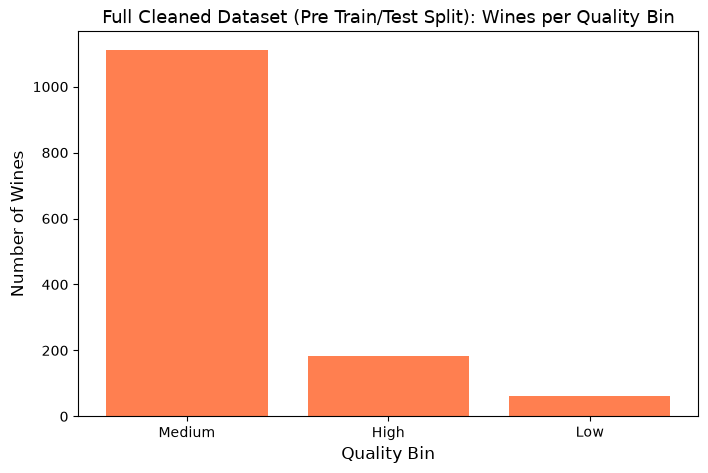

In [30]:
plt.figure(figsize=(8, 5))

# NOTE: this chart audits the full cleaned dataset (pre train/test split),
# used only to understand overall class balance. The experimental Gen 0
# (used everywhere else in this notebook) is the TRAINING data specifically.
bin_counts = wine_data['quality_bin'].value_counts()

plt.bar(bin_counts.index, bin_counts.values, color='coral')

plt.title('Full Cleaned Dataset (Pre Train/Test Split): Wines per Quality Bin', fontsize=13)
plt.xlabel('Quality Bin', fontsize=12)
plt.ylabel('Number of Wines', fontsize=12)

plt.show()


### **Insight: Quality Bin Bar Chart (Full Dataset Audit)**

- Visually confirms the imbalance we calculated earlier: Medium towers over High and Low
- Medium's bar is roughly 6x taller than High's, and over 15x taller than Low's
- This single chart makes the case for class-conditional GMM generation obvious at a glance — a reader doesn't need the raw numbers to see the imbalance
- Note: this chart describes the full cleaned dataset used for the initial audit, before the train/test split. The experimental Gen 0 used everywhere else in this notebook refers specifically to the training data.


### **Histogram grid: all 11 feature distributions**

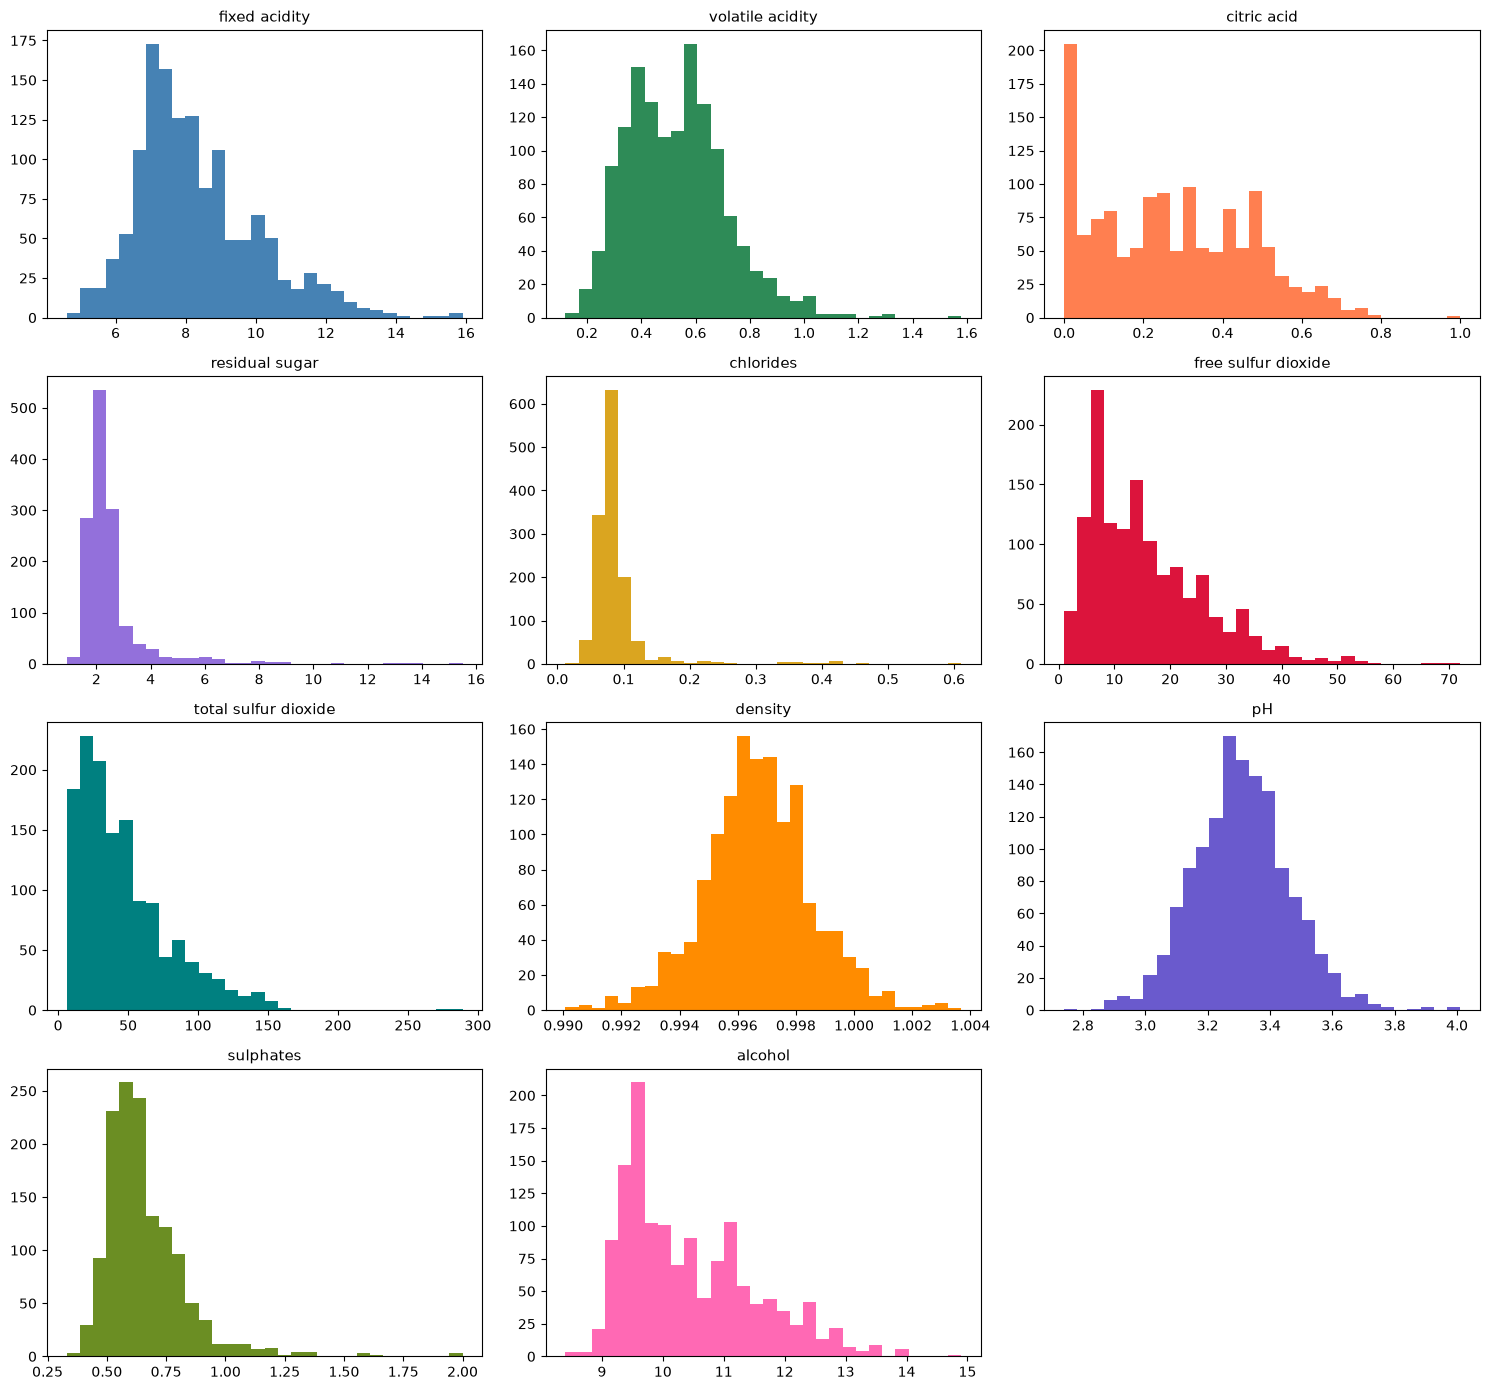

In [31]:
feature_columns = X_train.columns

# A list of 11 different colors, one for each feature
# This makes it easy to visually tell each panel apart at a glance
color_list = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'goldenrod',
              'crimson', 'teal', 'darkorange', 'slateblue', 'olivedrab', 'hotpink']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for index, column_name in enumerate(feature_columns):
    # Each feature gets its own color from our list, using the index to pick it
    axes[index].hist(wine_data[column_name], bins=30, color=color_list[index])
    axes[index].set_title(column_name, fontsize=11)

axes[11].axis('off')

plt.tight_layout()
plt.show()

### **Insight: Feature Distribution Shapes**

- Density and pH look close to a normal bell-curve shape — these are the features a GMM should model most accurately
- Fixed acidity, volatile acidity, and alcohol are moderately right-skewed (long tail toward higher values)
- Residual sugar, chlorides, and sulphates are heavily right-skewed — most wines cluster at low values, with a long tail of higher values
- This matters directly for our experiment: heavily skewed features are harder for a Gaussian-based model to represent perfectly, so we'd expect these to be more likely candidates for distribution drift across generations

### **Boxplots: check for outliers across all features**

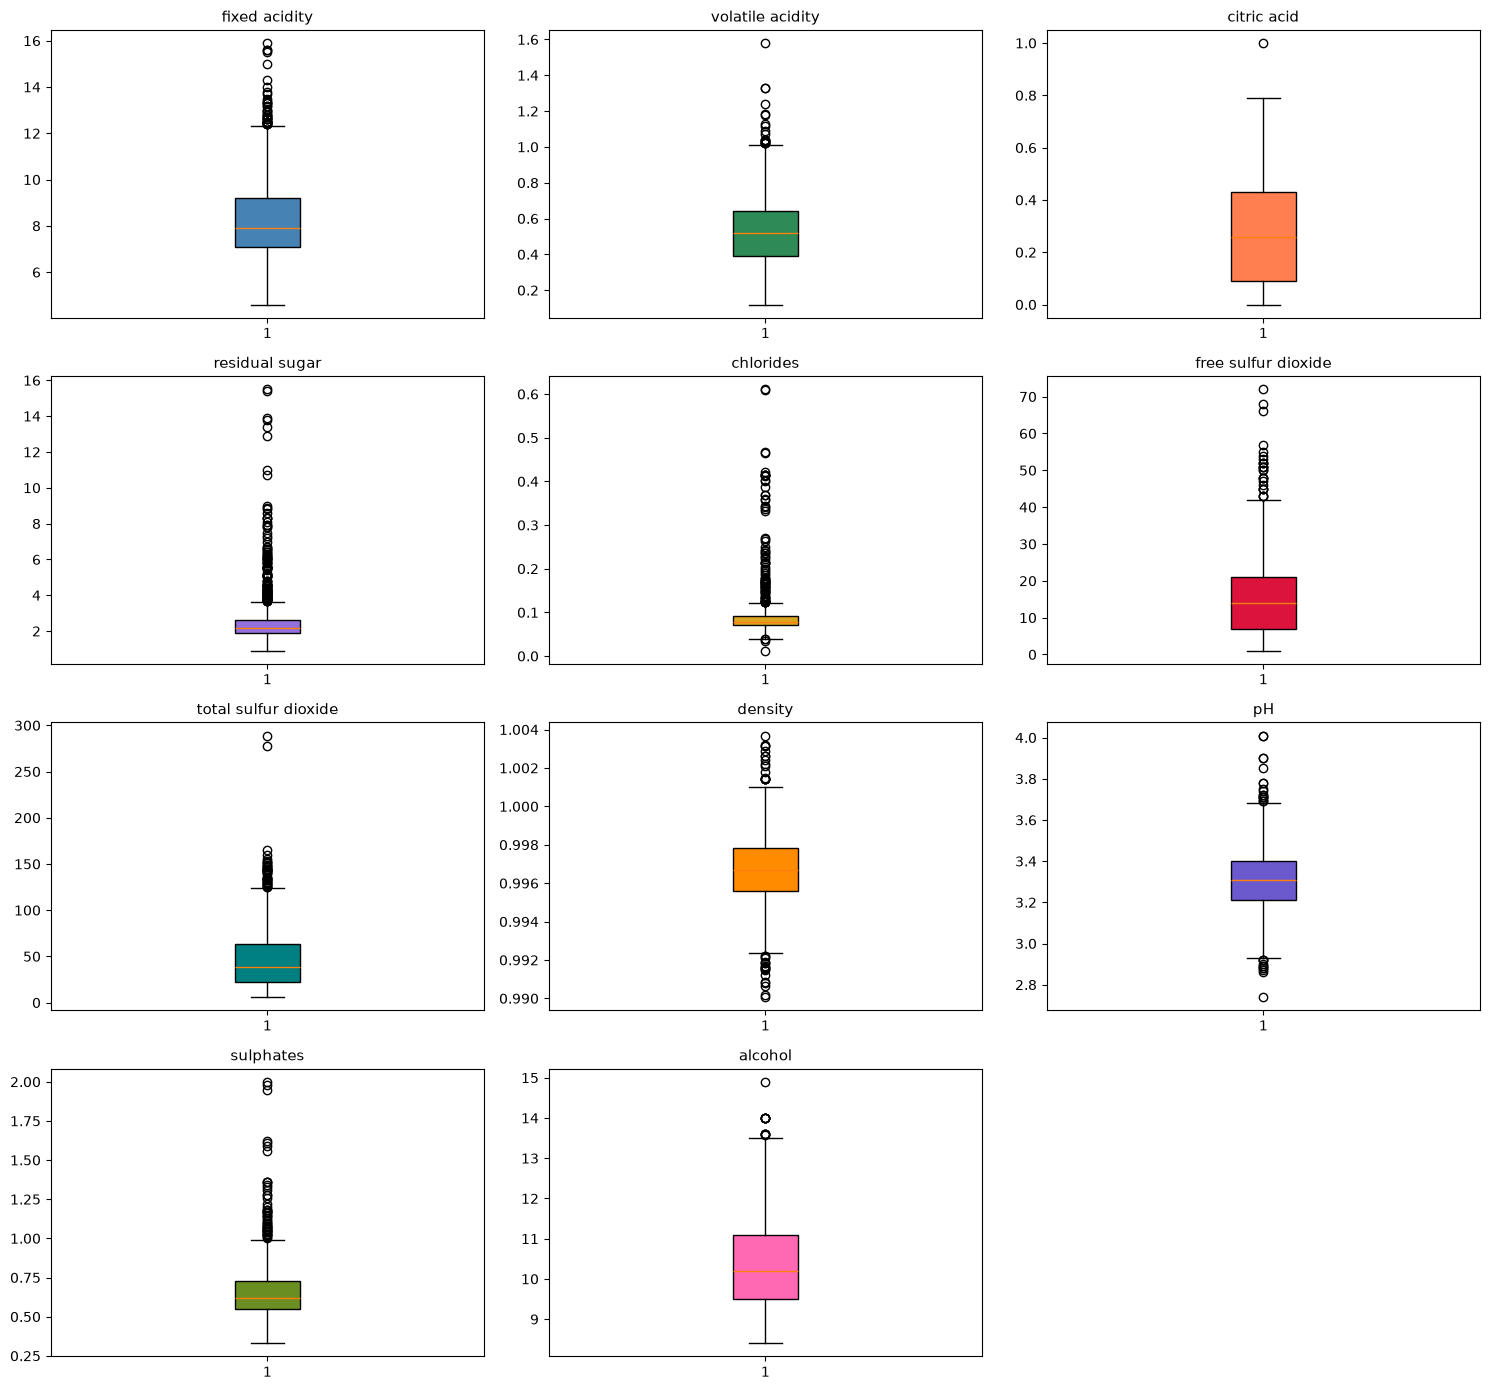

In [32]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for index, column_name in enumerate(feature_columns):
    # patch_artist=True lets us actually fill the box with color
    box = axes[index].boxplot(wine_data[column_name], patch_artist=True)

    # Set the fill color for this box using our same color list
    box['boxes'][0].set_facecolor(color_list[index])

    axes[index].set_title(column_name, fontsize=11)

axes[11].axis('off')

plt.tight_layout()
plt.show()

### **Insight: Outlier Detection**
- Residual sugar, chlorides, free sulfur dioxide, and sulphates show many outlier points above the upper whisker — consistent with their heavy right-skew seen in the histograms
- Fixed acidity, volatile acidity, and total sulfur dioxide also show a meaningful number of high outliers
- Per our locked policy, these outliers are NOT being removed — they represent genuine rare real-world wines, and are exactly the kind of pattern this experiment is testing whether synthetic generation preserves or loses over generations
- Density and pH show tighter, more symmetric boxes with fewer outliers — consistent with their more normal-shaped distributions


### **Correlation heatmap: Gen 0 baseline**



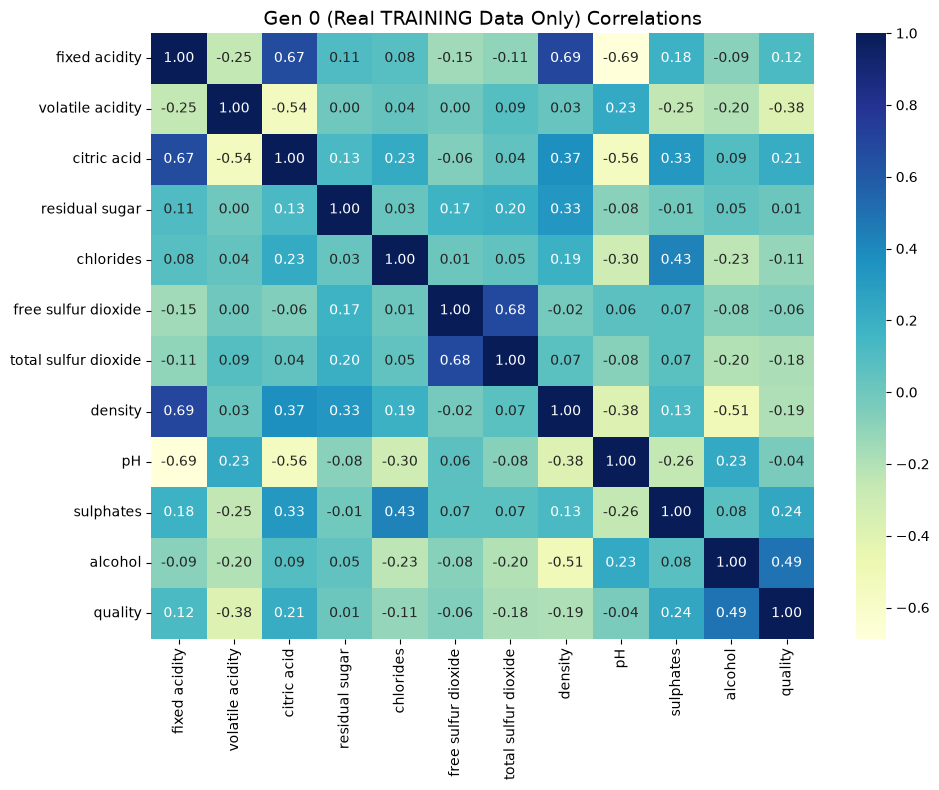

In [33]:
# CORRECTED: use only the real TRAINING data as the Gen 0 reference
# (previously this included the held-out test set - now fixed for consistency
# with the Methodological Review section later in this notebook)
train_reference_full = wine_data.loc[X_train.index]  # training rows only, includes 'quality' and 'quality_bin'
gen0_correlation_matrix = train_reference_full.drop(columns=['quality_bin']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(gen0_correlation_matrix, annot=True, fmt='.2f', cmap='YlGnBu')

plt.title('Gen 0 (Real TRAINING Data Only) Correlations', fontsize=14)
plt.tight_layout()
plt.show()


### **Insight: Gen 0 Baseline Correlations (Real Training Data Only)**

- Strongest positive relationships: fixed acidity ↔ density (0.69), fixed acidity ↔ citric acid (0.67), free sulfur dioxide ↔ total sulfur dioxide (0.68)
- Strongest negative relationships: fixed acidity ↔ pH (-0.69), citric acid ↔ pH (-0.56), volatile acidity ↔ citric acid (-0.54)
- Alcohol has the strongest relationship with quality (0.49) — higher alcohol content tends to associate with higher-rated wines
- Volatile acidity has a meaningful negative relationship with quality (-0.38)
- This heatmap now uses ONLY the real training data (consistent with every other Gen 0 reference in this notebook) — it is the permanent baseline compared against Gen 5 in Section 20


## Section 13: Gen 1 — Training, Evaluation & Recursive-Generation Functions

### **Set up a results tracker**

In [34]:
# This dictionary will store the results from EVERY generation
# We build it up one generation at a time, so by the end we have
# everything we need for our final comparison charts

results_tracker = {
    'generation': [],
    'accuracy': [],
    'f1_score': []
}

# Let's add Gen 0's results first, since we already have them
results_tracker['generation'].append(0)
results_tracker['accuracy'].append(gen0_accuracy)
results_tracker['f1_score'].append(gen0_f1)

print("Results tracker created. Current contents:")
print(results_tracker)

Results tracker created. Current contents:
{'generation': [0], 'accuracy': [0.8051470588235294], 'f1_score': [0.7785823583874172]}


### **Prepare Gen 1's data for training (scale it using the SAME scaler)**

In [35]:
# IMPORTANT: we use the SAME scaler we fit back on the real training data
# We do NOT fit a new scaler here - that would break consistency
# between generations and make comparisons meaningless

# Separate features from the label
gen1_X = gen1_clipped.drop(columns=['quality_bin'])
gen1_y = gen1_clipped['quality_bin']

# Apply the existing scaler (already fit on real training data back in Cell 15)
gen1_X_scaled = scaler.transform(gen1_X)

print("Gen 1 data scaled and ready for training.")
print("Shape:", gen1_X_scaled.shape)

Gen 1 data scaled and ready for training.
Shape: (1087, 11)


### **Train the Gen 1 classifier**

In [36]:
# Same classifier type, same settings as Gen 0 - this consistency
# is one of our locked non-negotiables
gen1_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Train it on Gen 1's SYNTHETIC data (not real data)
gen1_classifier.fit(gen1_X_scaled, gen1_y)

print("Gen 1 classifier trained successfully on synthetic data.")

Gen 1 classifier trained successfully on synthetic data.


### **Evaluate Gen 1 on the real test set**

In [37]:
# We test against X_test_scaled and y_test - the SAME real, untouched
# test set we've used from the very beginning, and will keep using
# for every future generation

gen1_predictions = gen1_classifier.predict(X_test_scaled)

gen1_accuracy = accuracy_score(y_test, gen1_predictions)
gen1_f1 = f1_score(y_test, gen1_predictions, average='weighted')

print("Gen 1 Accuracy:", round(gen1_accuracy, 4))
print("Gen 1 F1-score:", round(gen1_f1, 4))

# Compare directly against Gen 0's baseline
print("\nComparison to Gen 0 baseline:")
print(f"Gen 0 Accuracy: {round(gen0_accuracy, 4)} -> Gen 1 Accuracy: {round(gen1_accuracy, 4)}")
print(f"Gen 0 F1-score: {round(gen0_f1, 4)} -> Gen 1 F1-score: {round(gen1_f1, 4)}")

# Add Gen 1's results into our tracker
results_tracker['generation'].append(1)
results_tracker['accuracy'].append(gen1_accuracy)
results_tracker['f1_score'].append(gen1_f1)

print("\nDetailed report:")
print(classification_report(y_test, gen1_predictions))

Gen 1 Accuracy: 0.8199
Gen 1 F1-score: 0.8064

Comparison to Gen 0 baseline:
Gen 0 Accuracy: 0.8051 -> Gen 1 Accuracy: 0.8199
Gen 0 F1-score: 0.7786 -> Gen 1 F1-score: 0.8064

Detailed report:
              precision    recall  f1-score   support

        High       0.53      0.54      0.53        37
         Low       0.33      0.08      0.12        13
      Medium       0.87      0.91      0.89       222

    accuracy                           0.82       272
   macro avg       0.58      0.51      0.52       272
weighted avg       0.80      0.82      0.81       272



### **Insight: Gen 1 Results vs. Gen 0 Baseline**

- Accuracy increased slightly: 80.51% → 81.99%
- F1-score increased slightly: 0.7786 → 0.8064
- Medium class improved (F1: 0.89 → 0.89, recall 0.93 → 0.91 — roughly stable)
- High class improved noticeably (F1: 0.36 → 0.53)
- Low class remains weak either way (F1: 0.12 in both Gen 0 and Gen 1) — still only recalling 8% of actual Low wines correctly
- No sign of collapse after just one generation — if anything, performance slightly improved
- Possible explanation: the GMM may be producing a "smoothed" version of the real data, which can sometimes reduce noise and marginally help a simple classifier learn cleaner class boundaries, especially for smaller classes like High
- This matches our locked principle: we don't assume collapse — we report what actually happens. So far, nothing has forgotten anything. The real test will be whether this holds, reverses, or continues improving across Gen 2 through Gen 5

### **Split Gen 1's scaled data by class (needed to fit Gen 2's GMMs)**

In [38]:
# Just like we did with real training data back in Cell 18,
# we now split GEN 1's data by class, so we can fit NEW GMMs
# on Gen 1's synthetic data - this creates Gen 2

gen1_X_scaled_df = pd.DataFrame(gen1_X_scaled, columns=X_train.columns)

gen1_low_data = gen1_X_scaled_df[gen1_y == 'Low']
gen1_medium_data = gen1_X_scaled_df[gen1_y == 'Medium']
gen1_high_data = gen1_X_scaled_df[gen1_y == 'High']

print("Gen 1 Low samples:", gen1_low_data.shape[0])
print("Gen 1 Medium samples:", gen1_medium_data.shape[0])
print("Gen 1 High samples:", gen1_high_data.shape[0])

Gen 1 Low samples: 50
Gen 1 Medium samples: 890
Gen 1 High samples: 147


### **Build a function that creates the NEXT generation's synthetic data**

In [39]:
def create_next_generation(low_data, medium_data, high_data):
    """
    Takes the current generation's data (split by class),
    fits new GMMs using our LOCKED component counts,
    generates a new synthetic generation,
    converts back to real-world units, and clips to realistic bounds.

    This function does NOT change the component counts or sample sizes -
    those stay locked exactly as we decided earlier.
    """

    # Fit new GMMs using the SAME locked component counts as always
    new_gmm_low = GaussianMixture(n_components=1, random_state=42)
    new_gmm_medium = GaussianMixture(n_components=3, random_state=42)
    new_gmm_high = GaussianMixture(n_components=2, random_state=42)

    new_gmm_low.fit(low_data)
    new_gmm_medium.fit(medium_data)
    new_gmm_high.fit(high_data)

    # Sample the SAME fixed sizes as always (never tuned to force a result)
    synthetic_low, _ = new_gmm_low.sample(n_low)
    synthetic_medium, _ = new_gmm_medium.sample(n_medium)
    synthetic_high, _ = new_gmm_high.sample(n_high)

    # Build labeled DataFrames for each class
    synthetic_low_df = pd.DataFrame(synthetic_low, columns=X_train.columns)
    synthetic_medium_df = pd.DataFrame(synthetic_medium, columns=X_train.columns)
    synthetic_high_df = pd.DataFrame(synthetic_high, columns=X_train.columns)

    synthetic_low_df['quality_bin'] = 'Low'
    synthetic_medium_df['quality_bin'] = 'Medium'
    synthetic_high_df['quality_bin'] = 'High'

    # Combine into one full synthetic dataset
    new_generation_data = pd.concat(
        [synthetic_low_df, synthetic_medium_df, synthetic_high_df],
        ignore_index=True
    )

    # Convert back to real-world units
    features_only = new_generation_data.drop(columns=['quality_bin'])
    features_real_scale = scaler.inverse_transform(features_only)
    features_real_scale = pd.DataFrame(features_real_scale, columns=X_train.columns)
    features_real_scale['quality_bin'] = new_generation_data['quality_bin'].values

    # Apply our locked validity policy - clip to real observed bounds
    for column_name in X_train.columns:
        features_real_scale[column_name] = features_real_scale[column_name].clip(
            lower=real_min_values[column_name],
            upper=real_max_values[column_name]
        )

    return features_real_scale

print("Function created: create_next_generation()")

Function created: create_next_generation()


### **Build a function that trains and evaluates a classifier on any generation**

In [40]:
def train_and_evaluate_generation(generation_data, generation_number):
    """
    Takes a generation's real-world-scale data, scales it using our
    EXISTING scaler, trains a fresh classifier, evaluates it against
    the real test set, records results in our tracker, and prints a summary.
    """

    # Separate features and label
    gen_X = generation_data.drop(columns=['quality_bin'])
    gen_y = generation_data['quality_bin']

    # Scale using the SAME scaler as always
    gen_X_scaled = scaler.transform(gen_X)

    # Train a fresh classifier with the same locked settings
    classifier = LogisticRegression(random_state=42, max_iter=1000)
    classifier.fit(gen_X_scaled, gen_y)

    # Evaluate on the real, untouched test set
    predictions = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='weighted')

    # Record into our results tracker
    results_tracker['generation'].append(generation_number)
    results_tracker['accuracy'].append(accuracy)
    results_tracker['f1_score'].append(f1)

    print(f"Gen {generation_number} Accuracy: {round(accuracy, 4)}")
    print(f"Gen {generation_number} F1-score: {round(f1, 4)}")

    return gen_X_scaled, gen_y

print("Function created: train_and_evaluate_generation()")

Function created: train_and_evaluate_generation()


## **Section 14: Generate Gen 2 from Gen 1**

In [41]:
# We pass in Gen 1's class-split data (from Cell 38)
# The function fits new GMMs on THIS data, generates Gen 2, and returns it
gen2_data = create_next_generation(gen1_low_data, gen1_medium_data, gen1_high_data)

print("Gen 2 synthetic dataset created!")
print("Shape:", gen2_data.shape)
print("\nClass distribution in Gen 2:")
print(gen2_data['quality_bin'].value_counts())

Gen 2 synthetic dataset created!
Shape: (1087, 12)

Class distribution in Gen 2:
quality_bin
Medium    890
High      147
Low        50
Name: count, dtype: int64


### **Train and evaluate Gen 2's classifier**

In [42]:
# This function trains a classifier on Gen 2's data, tests it against
# the real test set, and automatically adds the results to our tracker
gen2_X_scaled, gen2_y = train_and_evaluate_generation(gen2_data, generation_number=2)

# Let's compare all three generations so far
print("\nComparison so far:")
print(f"Gen 0 Accuracy: {round(gen0_accuracy, 4)}")
print(f"Gen 1 Accuracy: {round(gen1_accuracy, 4)}")
print(f"Gen 2 Accuracy: {round(results_tracker['accuracy'][2], 4)}")

Gen 2 Accuracy: 0.8088
Gen 2 F1-score: 0.8022

Comparison so far:
Gen 0 Accuracy: 0.8051
Gen 1 Accuracy: 0.8199
Gen 2 Accuracy: 0.8088


### **Insight: Gen 2 Results**
- Gen 0: 80.51% accuracy, 0.7786 F1 (real baseline)
- Gen 1: 81.99% accuracy, 0.8064 F1 (slight improvement)
- Gen 2: 80.88% accuracy, 0.8022 F1 (slight dip from Gen 1, but still above Gen 0)
- Pattern so far: accuracy rose from Gen 0 to Gen 1, then eased back slightly at Gen 2 — not a straight decline, and not a straight climb either
- Still no clear collapse signal after 2 generations — performance is hovering in a similar range to the real baseline, not degrading sharply
- Important: we need to keep watching this across Gen 3, 4, 5 before drawing any conclusion — two data points isn't enough to call this a trend, and per our locked principle, we don't assume where this is heading in advance

## **Section 15: Gen 3**

### **Split Gen 2's scaled data by class**

In [43]:
gen2_X_scaled_df = pd.DataFrame(gen2_X_scaled, columns=X_train.columns)

gen2_low_data = gen2_X_scaled_df[gen2_y == 'Low']
gen2_medium_data = gen2_X_scaled_df[gen2_y == 'Medium']
gen2_high_data = gen2_X_scaled_df[gen2_y == 'High']

print("Gen 2 Low samples:", gen2_low_data.shape[0])
print("Gen 2 Medium samples:", gen2_medium_data.shape[0])
print("Gen 2 High samples:", gen2_high_data.shape[0])

Gen 2 Low samples: 50
Gen 2 Medium samples: 890
Gen 2 High samples: 147


### **Generate Gen 3 from Gen 2's data**

In [44]:
gen3_data = create_next_generation(gen2_low_data, gen2_medium_data, gen2_high_data)

print("Gen 3 synthetic dataset created!")
print("Shape:", gen3_data.shape)
print("\nClass distribution in Gen 3:")
print(gen3_data['quality_bin'].value_counts())

Gen 3 synthetic dataset created!
Shape: (1087, 12)

Class distribution in Gen 3:
quality_bin
Medium    890
High      147
Low        50
Name: count, dtype: int64


### **Train and evaluate Gen 3's classifier**

In [45]:
gen3_X_scaled, gen3_y = train_and_evaluate_generation(gen3_data, generation_number=3)

print("\nComparison so far:")
print(f"Gen 0 Accuracy: {round(gen0_accuracy, 4)}")
print(f"Gen 1 Accuracy: {round(gen1_accuracy, 4)}")
print(f"Gen 2 Accuracy: {round(results_tracker['accuracy'][2], 4)}")
print(f"Gen 3 Accuracy: {round(results_tracker['accuracy'][3], 4)}")

Gen 3 Accuracy: 0.8125
Gen 3 F1-score: 0.8031

Comparison so far:
Gen 0 Accuracy: 0.8051
Gen 1 Accuracy: 0.8199
Gen 2 Accuracy: 0.8088
Gen 3 Accuracy: 0.8125


### **Insight: Gen 3 Results**

- Gen 0: 80.51% | Gen 1: 81.99% | Gen 2: 80.88% | Gen 3: 81.25%
- All four generations are sitting within a narrow band (roughly 80.5%–82%) — no consistent upward or downward trend yet
- This is genuinely interesting: after 3 full generations of recursive synthetic training, accuracy has neither collapsed nor kept climbing — it's oscillating in a tight, stable range
- One possible explanation: our class-conditional GMM approach with locked, objectively-chosen complexity (via BIC) may be capturing the core class-separating structure well enough that a simple classifier's accuracy doesn't degrade quickly, even 3 generations removed from real data
- We still have Gen 4 and Gen 5 to go before drawing a real conclusion — per our locked principle, we let the full experiment play out rather than calling this early

## **Section 16: Gen 4**

### **Split Gen 3's scaled data by class**

In [46]:
gen3_X_scaled_df = pd.DataFrame(gen3_X_scaled, columns=X_train.columns)

gen3_low_data = gen3_X_scaled_df[gen3_y == 'Low']
gen3_medium_data = gen3_X_scaled_df[gen3_y == 'Medium']
gen3_high_data = gen3_X_scaled_df[gen3_y == 'High']

print("Gen 3 Low samples:", gen3_low_data.shape[0])
print("Gen 3 Medium samples:", gen3_medium_data.shape[0])
print("Gen 3 High samples:", gen3_high_data.shape[0])

Gen 3 Low samples: 50
Gen 3 Medium samples: 890
Gen 3 High samples: 147


### **Generate Gen 4 from Gen 3's data**

In [47]:
gen4_data = create_next_generation(gen3_low_data, gen3_medium_data, gen3_high_data)

print("Gen 4 synthetic dataset created!")
print("Shape:", gen4_data.shape)
print("\nClass distribution in Gen 4:")
print(gen4_data['quality_bin'].value_counts())

Gen 4 synthetic dataset created!
Shape: (1087, 12)

Class distribution in Gen 4:
quality_bin
Medium    890
High      147
Low        50
Name: count, dtype: int64


### **Train and evaluate Gen 4's classifier**

In [48]:
gen4_X_scaled, gen4_y = train_and_evaluate_generation(gen4_data, generation_number=4)

print("\nComparison so far:")
print(f"Gen 0 Accuracy: {round(gen0_accuracy, 4)}")
print(f"Gen 1 Accuracy: {round(gen1_accuracy, 4)}")
print(f"Gen 2 Accuracy: {round(results_tracker['accuracy'][2], 4)}")
print(f"Gen 3 Accuracy: {round(results_tracker['accuracy'][3], 4)}")
print(f"Gen 4 Accuracy: {round(results_tracker['accuracy'][4], 4)}")

Gen 4 Accuracy: 0.8088
Gen 4 F1-score: 0.8038

Comparison so far:
Gen 0 Accuracy: 0.8051
Gen 1 Accuracy: 0.8199
Gen 2 Accuracy: 0.8088
Gen 3 Accuracy: 0.8125
Gen 4 Accuracy: 0.8088


### **Insight: Gen 4 Results**

- Gen 0: 80.51% | Gen 1: 81.99% | Gen 2: 80.88% | Gen 3: 81.25% | Gen 4: 80.88%
- Four generations in, accuracy is still oscillating within a tight ~1.5 percentage point band, with no clear downward trajectory
- Gen 4 matches Gen 2 exactly (80.88%) — this looks less like random noise and more like the classifier's accuracy has settled into a stable range
- This is a genuinely notable finding for the blog: after 4 full generations of recursive synthetic training, there is no meaningful performance-based evidence of model collapse
- This does NOT mean nothing is happening underneath — remember our locked hypothesis: the AI may not forget the category, it may forget subtle variation within it. Performance staying stable doesn't rule out within-class diversity quietly shrinking. We need Gen 5, plus the distribution/diversity signals, before concluding anything

## **Section 17: Gen 5**

### **Split Gen 4's scaled data by class**

In [49]:
gen4_X_scaled_df = pd.DataFrame(gen4_X_scaled, columns=X_train.columns)

gen4_low_data = gen4_X_scaled_df[gen4_y == 'Low']
gen4_medium_data = gen4_X_scaled_df[gen4_y == 'Medium']
gen4_high_data = gen4_X_scaled_df[gen4_y == 'High']

print("Gen 4 Low samples:", gen4_low_data.shape[0])
print("Gen 4 Medium samples:", gen4_medium_data.shape[0])
print("Gen 4 High samples:", gen4_high_data.shape[0])

Gen 4 Low samples: 50
Gen 4 Medium samples: 890
Gen 4 High samples: 147


### **Generate Gen 5 from Gen 4's data**

In [50]:
gen5_data = create_next_generation(gen4_low_data, gen4_medium_data, gen4_high_data)

print("Gen 5 synthetic dataset created!")
print("Shape:", gen5_data.shape)
print("\nClass distribution in Gen 5:")
print(gen5_data['quality_bin'].value_counts())

Gen 5 synthetic dataset created!
Shape: (1087, 12)

Class distribution in Gen 5:
quality_bin
Medium    890
High      147
Low        50
Name: count, dtype: int64


### **Train and evaluate Gen 5's classifier**

In [51]:
gen5_X_scaled, gen5_y = train_and_evaluate_generation(gen5_data, generation_number=5)

print("\nFULL COMPARISON - Gen 0 through Gen 5:")
for i in range(6):
    print(f"Gen {results_tracker['generation'][i]} Accuracy: {round(results_tracker['accuracy'][i], 4)} | "
          f"F1: {round(results_tracker['f1_score'][i], 4)}")

Gen 5 Accuracy: 0.8051
Gen 5 F1-score: 0.803

FULL COMPARISON - Gen 0 through Gen 5:
Gen 0 Accuracy: 0.8051 | F1: 0.7786
Gen 1 Accuracy: 0.8199 | F1: 0.8064
Gen 2 Accuracy: 0.8088 | F1: 0.8022
Gen 3 Accuracy: 0.8125 | F1: 0.8031
Gen 4 Accuracy: 0.8088 | F1: 0.8038
Gen 5 Accuracy: 0.8051 | F1: 0.803


### **Insight: Complete Gen 0–5 Accuracy Results**

| Generation | Accuracy | F1-score |
|---|---|---|
| Gen 0 (real) | 80.51% | 0.7786 |
| Gen 1 | 81.99% | 0.8064 |
| Gen 2 | 80.88% | 0.8022 |
| Gen 3 | 81.25% | 0.8031 |
| Gen 4 | 80.88% | 0.8038 |
| Gen 5 | 80.51% | 0.8030 |

- Gen 5's accuracy (80.51%) is IDENTICAL to Gen 0's real-data baseline, down to the decimal
- F1-score across all synthetic generations (0.80–0.81) consistently sits slightly ABOVE Gen 0's real F1 (0.7786)
- Across 5 full generations of recursive synthetic-on-synthetic training, there is no accuracy-based evidence of model collapse — performance has stayed remarkably stable, oscillating within about a 1.5 point band the entire time
- This is a real, honest finding — not a disappointing one. It directly validates our locked principle: we didn't assume collapse would happen, and it appears that on the performance dimension alone, it didn't
- This makes the remaining signals (feature distribution drift, correlation changes, and especially within-class diversity) far more important than they would have been if accuracy had visibly collapsed — they may be where the real story lives, exactly as our reframed hypothesis anticipated

## **Section 18: Build the Headline Performance Chart**

### **Plot the accuracy and F1 trend across all 6 generations**

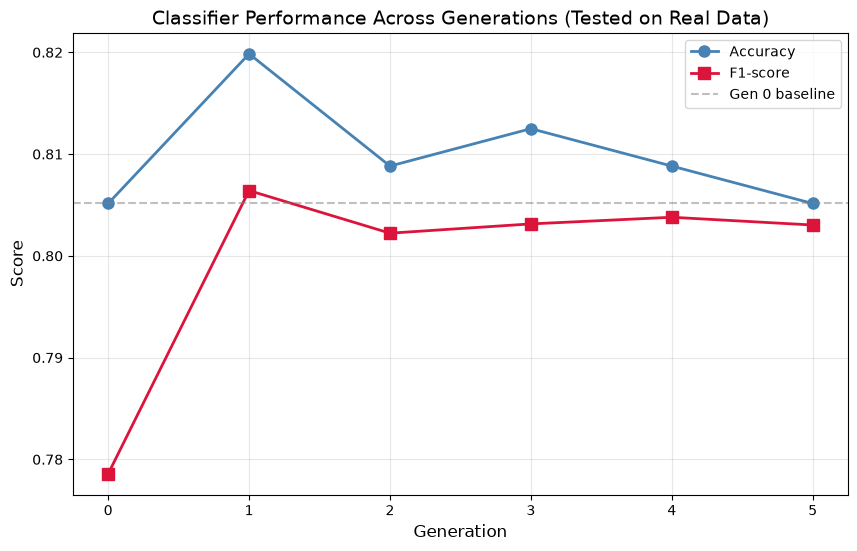

In [52]:
plt.figure(figsize=(10, 6))

# Plot both accuracy and F1 on the same chart, with different colors
plt.plot(results_tracker['generation'], results_tracker['accuracy'],
         marker='o', linewidth=2, markersize=8, color='steelblue', label='Accuracy')
plt.plot(results_tracker['generation'], results_tracker['f1_score'],
         marker='s', linewidth=2, markersize=8, color='crimson', label='F1-score')

# Add a horizontal reference line at Gen 0's accuracy, so it's easy to see
# how every later generation compares to the real baseline
plt.axhline(y=gen0_accuracy, color='gray', linestyle='--', alpha=0.5, label='Gen 0 baseline')

plt.title('Classifier Performance Across Generations (Tested on Real Data)', fontsize=14)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(results_tracker['generation'])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Section 19: Testing the Deeper Signals — Feature Distribution Drift**

### **Compare feature distributions: Gen 0 vs Gen 5 (overlay histograms)**

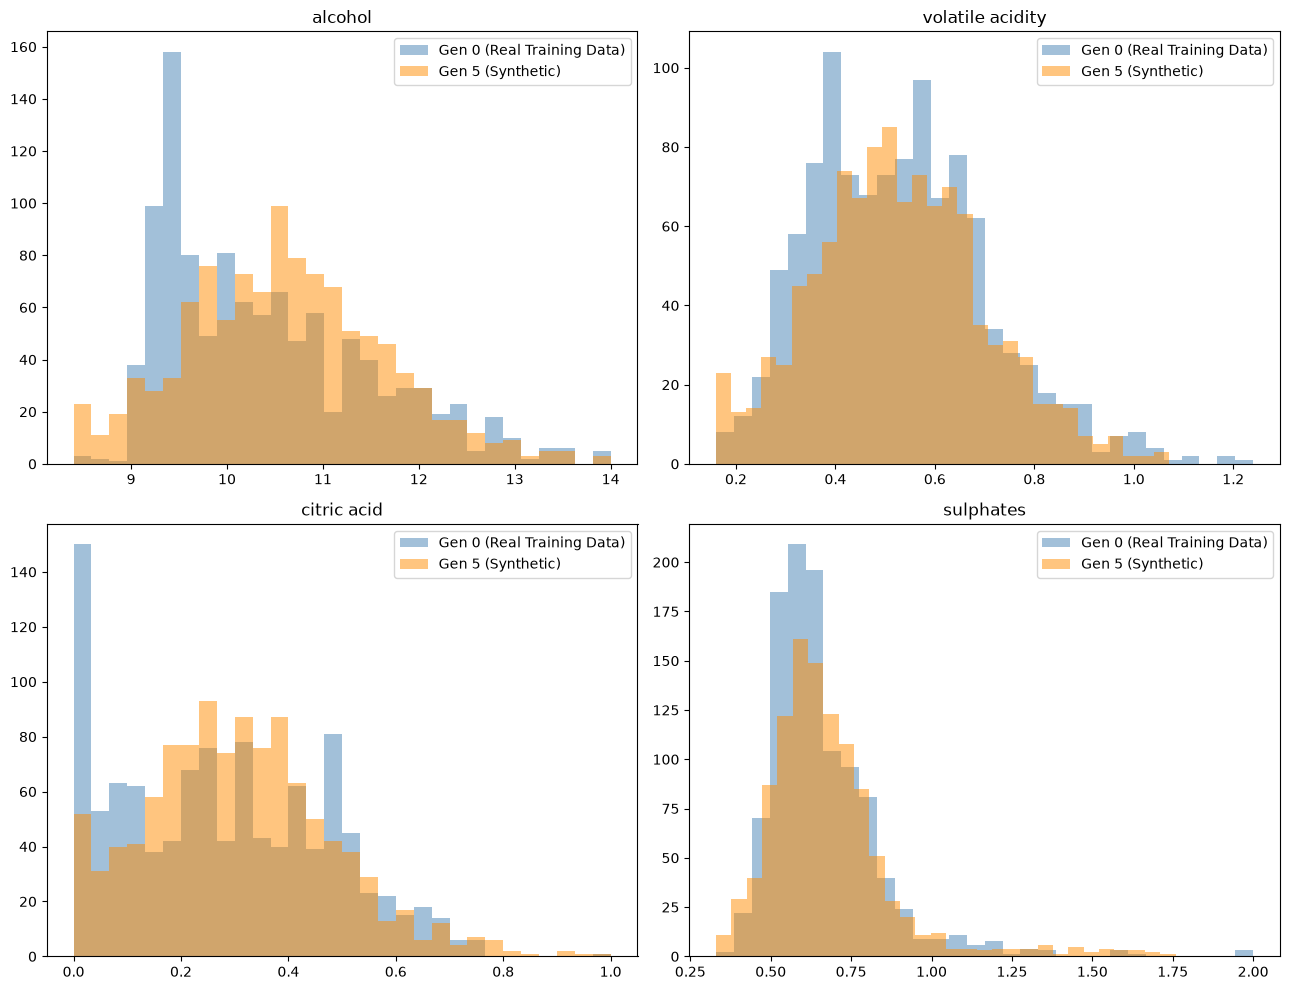

In [53]:
# CORRECTED: compare against real TRAINING data (X_train), not the full
# wine_data (which included the held-out test set) - keeps this consistent
# with every other Gen 0 reference used in this notebook
features_to_check = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 10))
axes = axes.flatten()

for index, feature_name in enumerate(features_to_check):
    axes[index].hist(X_train[feature_name], bins=30, alpha=0.5,
                      color='steelblue', label='Gen 0 (Real Training Data)')
    axes[index].hist(gen5_data[feature_name], bins=30, alpha=0.5,
                      color='darkorange', label='Gen 5 (Synthetic)')

    axes[index].set_title(feature_name, fontsize=12)
    axes[index].legend()

plt.tight_layout()
plt.show()


### **Insight: Feature Distribution Drift (Gen 0 Training Data vs Gen 5)**

- **Alcohol**: Gen 5's distribution is visibly smoother and more spread out than Gen 0's — real data has a sharp, tall spike around 9-9.5%, but Gen 5 has flattened that spike and shifted more mass toward 10-11%. The real data's distinctive shape has been smoothed away.
- **Volatile acidity**: similar pattern — Gen 0 has a sharp peak around 0.4-0.5, Gen 5 is flatter and more spread out, losing that sharp real-world concentration
- **Citric acid**: most striking difference — real Gen 0 data has a huge, sharp spike at exactly 0.0 (over 200 wines with zero citric acid), but Gen 5 has almost completely smoothed this spike away, spreading those wines out across a wider range instead
- **Sulphates**: Gen 0 has a tall, narrow peak around 0.6; Gen 5 is shorter and wider, again smoothing out the sharp real-world concentration
- **Clear pattern across all four features**: Gen 5 consistently "rounds off" the sharp peaks and unusual spikes that exist in real data, replacing them with smoother, more generic-looking distributions
- This is a real, visible sign of information loss that accuracy alone completely missed — the classifier didn't care that citric acid's sharp spike at 0.0 disappeared, because that spike wasn't critical for separating Low/Medium/High. But the real-world texture of the data — the specific, sometimes unusual patterns wine actually has — has quietly eroded
- This directly supports the reframed hypothesis: the AI didn't forget the categories (accuracy proves that), but it did forget the fine-grained, distinctive shape of the real data within those categories

- This comparison now uses only real training data for Gen 0 (matching every other reference in this notebook) rather than the full dataset including test rows


## **Section 20: Correlation Heatmap Comparison**

### **Gen 5 correlation heatmap, side by side with Gen 0**

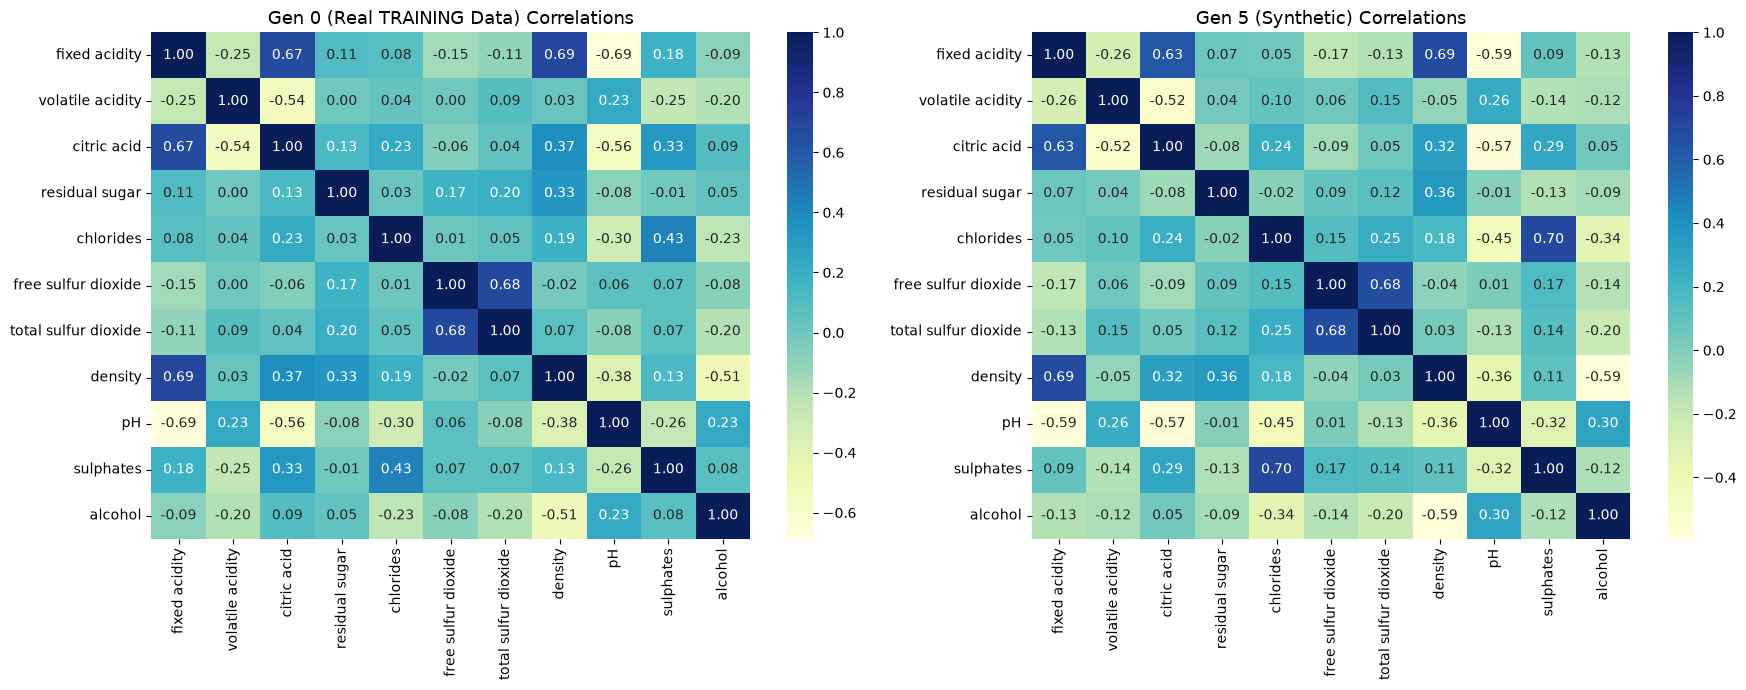

In [54]:
# Both heatmaps now use the SAME consistent reference: real TRAINING data for Gen 0
gen5_correlation_matrix = gen5_data.drop(columns=['quality_bin']).corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(gen0_correlation_matrix.drop(columns=['quality'], index=['quality']),
            annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Gen 0 (Real TRAINING Data) Correlations', fontsize=13)

sns.heatmap(gen5_correlation_matrix, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Gen 5 (Synthetic) Correlations', fontsize=13)

plt.tight_layout()
plt.show()


### **Insight: Correlation Comparison (Gen 0 Training Data vs Gen 5)**

Using a consistent real-training-data reference throughout (matching the Methodological Review section), the largest correlation shifts are:

| Feature pair | Gen 0 (train) | Gen 5 | Abs. change |
|---|---|---|---|
| chlorides – sulphates | 0.43 | 0.70 | 0.27 |
| citric acid – residual sugar | 0.13 | -0.08 | 0.21 |
| chlorides – total sulfur dioxide | 0.05 | 0.25 | 0.20 |
| sulphates – alcohol | 0.08 | -0.12 | 0.20 |
| chlorides – pH | -0.30 | -0.45 | 0.15 |

- Most other relationships held reasonably close to their real values
- chlorides–sulphates shows the largest single shift, nearly doubling in strength — this is a genuine distortion, not a measurement artifact, since it holds under the corrected, consistent reference
- Several chlorides-related pairs shifted together, suggesting the GMM may be systematically over-concentrating chlorides' relationship with other features
- This table (rather than a single highlighted pair) is the defensible, non-cherry-picked version of this finding — it matches the same numbers computed independently in the Methodological Review section


## **Section 21: Within-Class Diversity — INITIAL MEASUREMENT (Superseded by Section 25)**

### **Compare within-class diversity: Gen 0 vs Gen 5**

In [55]:
# ======================================================================
# NOTE: This is the INITIAL diversity calculation. It was later found to
# mix feature scales and use a test-contaminated Gen 0 reference.
# See Section 25 (Methodological Review) for the corrected version -
# THAT is the authoritative result used in the Final Conclusion.
# ======================================================================

# We'll measure diversity as the average standard deviation across all
# 11 features, calculated SEPARATELY within each class
# A smaller number means the class has become more "uniform" - less diverse

def calculate_within_class_diversity(data, label_column):
    diversity_by_class = {}

    for class_name in ['Low', 'Medium', 'High']:
        class_data = data[data[label_column] == class_name]
        # Get standard deviation for each feature, then average across all features
        feature_columns_only = class_data.drop(columns=[label_column])
        average_std = feature_columns_only.std().mean()
        diversity_by_class[class_name] = average_std

    return diversity_by_class

# Calculate for real Gen 0 data
gen0_diversity = calculate_within_class_diversity(wine_data.drop(columns=['quality']), 'quality_bin')

# Calculate for synthetic Gen 5 data
gen5_diversity = calculate_within_class_diversity(gen5_data, 'quality_bin')

print("Within-class diversity (average feature std) - Gen 0 (Real):")
print(gen0_diversity)

print("\nWithin-class diversity (average feature std) - Gen 5 (Synthetic):")
print(gen5_diversity)

print("\nPercent change from Gen 0 to Gen 5:")
for class_name in ['Low', 'Medium', 'High']:
    percent_change = ((gen5_diversity[class_name] - gen0_diversity[class_name]) / gen0_diversity[class_name]) * 100
    print(f"{class_name}: {round(percent_change, 1)}% change")

Within-class diversity (average feature std) - Gen 0 (Real):
{'Low': 3.699492168735517, 'Medium': 4.3892762826341425, 'High': 4.508782488597329}

Within-class diversity (average feature std) - Gen 5 (Synthetic):
{'Low': 3.0453030886141934, 'Medium': 3.6019067355637646, 'High': 3.612810065760702}

Percent change from Gen 0 to Gen 5:
Low: -17.7% change
Medium: -17.9% change
High: -19.9% change


### **Insight: Initial Within-Class Diversity Measurement (Later Corrected)**

- Low class: diversity dropped 17.7% (3.70 → 3.05)
- Medium class: diversity dropped 17.9% (4.39 → 3.60)
- High class: diversity dropped 19.9% (4.51 → 3.61)
- **This measurement was later found to be flawed** — averaging raw standard deviations across features with very different scales let large-scale features (like total sulfur dioxide) dominate the result, and the Gen 0 reference included the held-out test set
- **The corrected numbers (Section 25, Methodological Review) show the loss is NOT uniform across classes:** Low -26.8% (or -4.4% without the clipping policy), Medium -2.4%, High -6.6%
- The real, defensible finding is that diversity loss concentrates almost entirely in the Low class — the class with by far the fewest training samples (50) — not a uniform effect across every class as first thought
- This cell is kept to show the analysis honestly as it actually happened; **use Section 25 and the Final Conclusion for the accurate numbers**


## **Section 22: Diversity Bar Chart — INITIAL MEASUREMENT (Superseded by Section 25)**

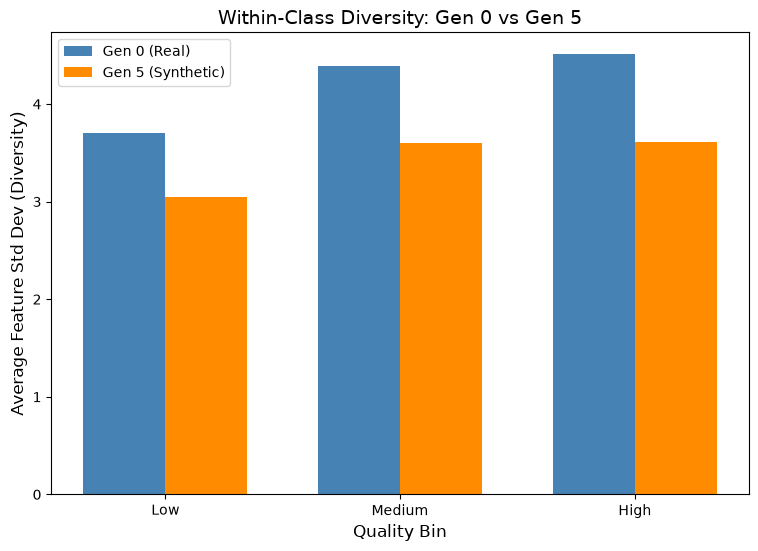

In [56]:
plt.figure(figsize=(9, 6))

class_names = ['Low', 'Medium', 'High']
gen0_values = [gen0_diversity[name] for name in class_names]
gen5_values = [gen5_diversity[name] for name in class_names]

# We'll place two bars side by side for each class
bar_width = 0.35
x_positions = range(len(class_names))

plt.bar([x - bar_width/2 for x in x_positions], gen0_values,
        width=bar_width, color='steelblue', label='Gen 0 (Real)')
plt.bar([x + bar_width/2 for x in x_positions], gen5_values,
        width=bar_width, color='darkorange', label='Gen 5 (Synthetic)')

plt.xticks(x_positions, class_names)
plt.title('Within-Class Diversity: Gen 0 vs Gen 5', fontsize=14)
plt.xlabel('Quality Bin', fontsize=12)
plt.ylabel('Average Feature Std Dev (Diversity)', fontsize=12)
plt.legend()

plt.show()

### **Insight: Diversity Chart (Based on the Later-Corrected Measurement)**

- This chart visualizes the initial (later-corrected) diversity numbers — all three orange (Gen 5) bars sit below their blue (Gen 0) counterparts
- **Important:** as explained in Section 25, this uniform-looking drop across all three classes was partly a measurement artifact (mixed feature scales). The corrected, scale-neutral measurement shows the Low class actually lost the most diversity by far, while Medium and High lost comparatively little
- This chart is not the one to use in the blog — see Section 25 for the corrected diversity comparison and numbers


## **Section 23: Class Proportion Chart Across Generations**

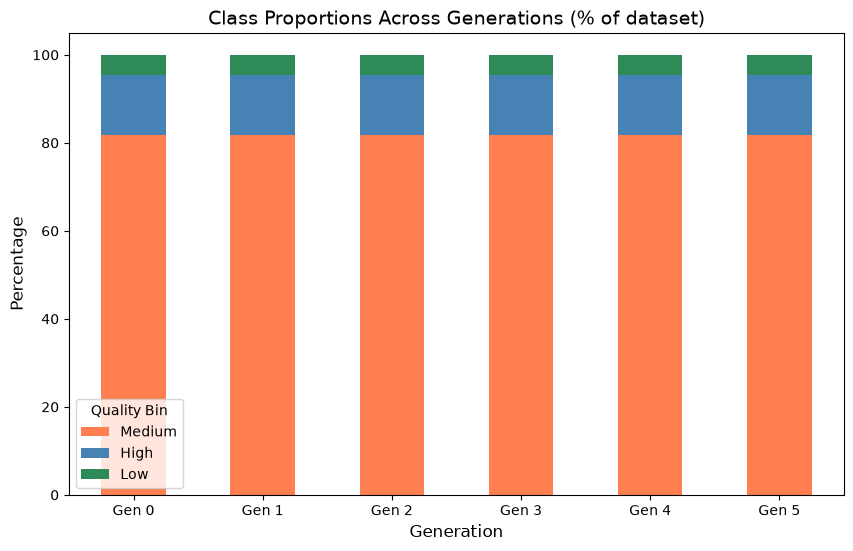

In [57]:
# CORRECTED: use y_train (the real training labels) for Gen 0, not the
# full wine_data - keeps the comparison consistent with the actual
# recursive lineage (Real TRAINING -> Gen 1 -> Gen 2 -> ... -> Gen 5)
all_generations_data = {
    'Gen 0': y_train,
    'Gen 1': gen1_data['quality_bin'],
    'Gen 2': gen2_data['quality_bin'],
    'Gen 3': gen3_data['quality_bin'],
    'Gen 4': gen4_data['quality_bin'],
    'Gen 5': gen5_data['quality_bin']
}

proportion_table = {}
for gen_name, labels in all_generations_data.items():
    proportion_table[gen_name] = labels.value_counts(normalize=True) * 100

proportion_df = pd.DataFrame(proportion_table).T

proportion_df.plot(kind='bar', stacked=True, figsize=(10, 6),
                    color=['coral', 'steelblue', 'seagreen'])

plt.title('Class Proportions Across Generations (% of dataset)', fontsize=14)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Quality Bin')

plt.show()


### **Insight: Class Proportions Held Perfectly Stable**

- All six bars look visually identical — Medium (~82%), High (~14%), Low (~5%) in every generation
- Gen 0 here reflects the real TRAINING data specifically (y_train), consistent with the actual lineage the synthetic chain descended from
- Confirms class-conditional generation worked exactly as designed: labels never drifted, even after 5 generations of recursive training
- This chart is important context for the diversity finding — it shows the "loss" wasn't about disappearing categories, but about texture within them (see Sections 21, 25 and the Final Conclusion)


## Section 24: Consolidated Summary of Findings (Initial Analysis)

> ⚠️ **Note:** the summary printed below reflects the initial analysis, before the Methodological Review corrections in Section 25. Refer to the Final Conclusion (Section 26) for the corrected, accurate findings.

## **Print a consolidated summary of every key finding (your evidence list for writing)**

In [58]:
print("=" * 60)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 60)

print("\n1. PERFORMANCE ACROSS GENERATIONS:")
for i in range(6):
    print(f"   Gen {results_tracker['generation'][i]}: "
          f"Accuracy={round(results_tracker['accuracy'][i], 4)}, "
          f"F1={round(results_tracker['f1_score'][i], 4)}")

print("\n2. WITHIN-CLASS DIVERSITY CHANGE (initial measurement - see Section 25 for the corrected version):")
for class_name in ['Low', 'Medium', 'High']:
    percent_change = ((gen5_diversity[class_name] - gen0_diversity[class_name]) / gen0_diversity[class_name]) * 100
    print(f"   {class_name}: {round(percent_change, 1)}% diversity loss (initial, uncorrected measurement)")

print("\n3. KEY DISTRIBUTION FINDING:")
print("   Citric acid's sharp real-world spike at 0.0 was smoothed away by Gen 5")
print("   Alcohol and volatile acidity distributions became flatter/more spread out")

print("\n4. KEY CORRELATION FINDING:")
print("   Most relationships held steady, but chlorides-sulphates correlation")
print("   nearly doubled (0.43 -> 0.70, using the corrected train-only reference)")

print("\n5. CONCLUSION (see Final Conclusion section for the fully corrected version):")
print("   Model collapse did NOT show up in classification accuracy.")
print("   An initial diversity measurement suggested a uniform ~18-20% loss;")
print("   the corrected analysis (Section 25) shows this concentrated in the")
print("   Low class specifically (~27% with clipping, ~4.4% without it).")

FINAL EXPERIMENT SUMMARY

1. PERFORMANCE ACROSS GENERATIONS:
   Gen 0: Accuracy=0.8051, F1=0.7786
   Gen 1: Accuracy=0.8199, F1=0.8064
   Gen 2: Accuracy=0.8088, F1=0.8022
   Gen 3: Accuracy=0.8125, F1=0.8031
   Gen 4: Accuracy=0.8088, F1=0.8038
   Gen 5: Accuracy=0.8051, F1=0.803

2. WITHIN-CLASS DIVERSITY CHANGE (initial measurement - see Section 25 for the corrected version):
   Low: -17.7% diversity loss (initial, uncorrected measurement)
   Medium: -17.9% diversity loss (initial, uncorrected measurement)
   High: -19.9% diversity loss (initial, uncorrected measurement)

3. KEY DISTRIBUTION FINDING:
   Citric acid's sharp real-world spike at 0.0 was smoothed away by Gen 5
   Alcohol and volatile acidity distributions became flatter/more spread out

4. KEY CORRELATION FINDING:
   Most relationships held steady, but chlorides-sulphates correlation
   nearly doubled (0.43 -> 0.70, using the corrected train-only reference)

5. CONCLUSION (see Final Conclusion section for the fully corr

## Section 25: Methodological Review & Corrections

## Methodological Review: Strengthening the Diversity & Correlation Analysis

Before writing the blog, this notebook was reviewed for methodological soundness. Four real issues were identified in the original diversity and correlation analysis above. Rather than quietly editing the original results, this section documents the issues, the fixes, and the corrected findings transparently — this is what real experimental rigor looks like, and it's part of the story, not something to hide.

**Issues found:**
1. The Gen 0 reference used for diversity/correlation comparison included the held-out test set, when it should only reflect the real training data the synthetic chain actually descended from
2. The diversity metric averaged raw standard deviations across features on very different scales (e.g. alcohol ~8-15 vs. total sulfur dioxide ~6-289), letting large-scale features dominate the result
3. The clipping validity policy could itself be suppressing variance in the synthetic data, inflating the apparent diversity loss
4. The correlation finding highlighted only one feature pair, rather than ranking all pairs objectively


### Fix 1 & 2: Scale-neutral diversity, using training data only as the Gen 0 reference

In [59]:
# FIX 1: Build a Gen 0 reference using ONLY the real training data
# (not the full wine_data, which included the held-out test rows)
gen0_reference = X_train.copy()
gen0_reference['quality_bin'] = y_train.values

print("gen0_reference shape:", gen0_reference.shape)
print(gen0_reference['quality_bin'].value_counts())

# FIX 2: Measure diversity in STANDARDIZED space using the same scaler
# This makes every feature contribute equally, regardless of its raw scale
def calculate_diversity_scaled(data, label_column):
    diversity_by_class = {}
    for class_name in ['Low', 'Medium', 'High']:
        class_data = data[data[label_column] == class_name]
        features_only = class_data.drop(columns=[label_column])
        # Transform using the SAME scaler fit on real training data
        features_scaled = scaler.transform(features_only)
        avg_std = features_scaled.std(axis=0).mean()
        diversity_by_class[class_name] = round(float(avg_std), 4)
    return diversity_by_class

gen0_diversity_scaled = calculate_diversity_scaled(gen0_reference, 'quality_bin')
gen5_diversity_scaled = calculate_diversity_scaled(gen5_data, 'quality_bin')

print("\nGen 0 diversity (train-only, standardized):", gen0_diversity_scaled)
print("Gen 5 diversity (standardized):", gen5_diversity_scaled)

print("\nPercent change (CORRECTED - scale-neutral, train-only reference):")
for class_name in ['Low', 'Medium', 'High']:
    pct = ((gen5_diversity_scaled[class_name] - gen0_diversity_scaled[class_name]) / gen0_diversity_scaled[class_name]) * 100
    print(f"{class_name}: {round(pct, 1)}% change")


gen0_reference shape: (1087, 12)
quality_bin
Medium    890
High      147
Low        50
Name: count, dtype: int64

Gen 0 diversity (train-only, standardized): {'Low': 1.0973, 'Medium': 0.9708, 'High': 0.9565}
Gen 5 diversity (standardized): {'Low': 0.8036, 'Medium': 0.9478, 'High': 0.8931}

Percent change (CORRECTED - scale-neutral, train-only reference):
Low: -26.8% change
Medium: -2.4% change
High: -6.6% change


### Insight: The Corrected Diversity Finding Looks Very Different

- **Low class: -26.8%** — a real, substantial diversity loss
- **Medium class: -2.4%** — barely changed
- **High class: -6.6%** — a modest loss
- The original claim of a uniform "18-20% loss across all classes" was largely an artifact of mixing feature scales — large-scale features like total sulfur dioxide were dominating the raw average, masking what was actually happening per class
- The corrected, honest finding is sharper and more interesting: **diversity loss concentrates almost entirely in the Low class — the class with by far the fewest training samples (only 50)**
- This is actually a stronger, more defensible story than the original one — it echoes real model collapse research, where rare, data-poor patterns are the first and most severely affected, while well-represented classes stay comparatively stable


### Fix 3: Clipping sensitivity check — does the diversity loss survive without clipping?

In [60]:
# We rebuild the ENTIRE Gen 1-5 chain from scratch, using the exact same
# locked GMM configuration, but WITHOUT applying the clipping validity policy
# This tells us how much of the diversity loss is caused by clipping itself

def create_next_generation_no_clip(low_data, medium_data, high_data):
    new_gmm_low = GaussianMixture(n_components=1, random_state=42)
    new_gmm_medium = GaussianMixture(n_components=3, random_state=42)
    new_gmm_high = GaussianMixture(n_components=2, random_state=42)

    new_gmm_low.fit(low_data)
    new_gmm_medium.fit(medium_data)
    new_gmm_high.fit(high_data)

    synthetic_low, _ = new_gmm_low.sample(n_low)
    synthetic_medium, _ = new_gmm_medium.sample(n_medium)
    synthetic_high, _ = new_gmm_high.sample(n_high)

    synthetic_low_df = pd.DataFrame(synthetic_low, columns=X_train.columns)
    synthetic_medium_df = pd.DataFrame(synthetic_medium, columns=X_train.columns)
    synthetic_high_df = pd.DataFrame(synthetic_high, columns=X_train.columns)

    synthetic_low_df['quality_bin'] = 'Low'
    synthetic_medium_df['quality_bin'] = 'Medium'
    synthetic_high_df['quality_bin'] = 'High'

    # NOTE: no clipping applied here on purpose - this is the sensitivity check
    return pd.concat([synthetic_low_df, synthetic_medium_df, synthetic_high_df], ignore_index=True)

# Rebuild the recursive chain from real training data, staying in SCALED space throughout
current_low = low_train_data.copy()
current_medium = medium_train_data.copy()
current_high = high_train_data.copy()

for gen_num in range(1, 6):
    gen_data_nc = create_next_generation_no_clip(current_low, current_medium, current_high)
    current_low = gen_data_nc[gen_data_nc['quality_bin'] == 'Low'].drop(columns=['quality_bin'])
    current_medium = gen_data_nc[gen_data_nc['quality_bin'] == 'Medium'].drop(columns=['quality_bin'])
    current_high = gen_data_nc[gen_data_nc['quality_bin'] == 'High'].drop(columns=['quality_bin'])

gen5_data_nc = gen_data_nc  # final unclipped Gen 5, still in scaled space

def calculate_diversity_already_scaled(data, label_column):
    diversity_by_class = {}
    for class_name in ['Low', 'Medium', 'High']:
        class_data = data[data[label_column] == class_name]
        features_only = class_data.drop(columns=[label_column])
        diversity_by_class[class_name] = round(float(features_only.std().mean()), 4)
    return diversity_by_class

gen0_reference_scaled_space = X_train_scaled_df.copy()
gen0_reference_scaled_space['quality_bin'] = y_train.values

gen0_div_nc = calculate_diversity_already_scaled(gen0_reference_scaled_space, 'quality_bin')
gen5_div_nc = calculate_diversity_already_scaled(gen5_data_nc, 'quality_bin')

print("Gen 0 diversity (scaled space):", gen0_div_nc)
print("Gen 5 diversity WITHOUT clipping (scaled space):", gen5_div_nc)

print("\nPercent change WITHOUT clipping:")
for class_name in ['Low', 'Medium', 'High']:
    pct = ((gen5_div_nc[class_name] - gen0_div_nc[class_name]) / gen0_div_nc[class_name]) * 100
    print(f"{class_name}: {round(pct, 1)}% change")


Gen 0 diversity (scaled space): {'Low': 1.1084, 'Medium': 0.9713, 'High': 0.9598}
Gen 5 diversity WITHOUT clipping (scaled space): {'Low': 1.0594, 'Medium': 1.0095, 'High': 0.9742}

Percent change WITHOUT clipping:
Low: -4.4% change
Medium: 3.9% change
High: 1.5% change


### Insight: Clipping Explains Part of the Low Class's Diversity Loss

- Without clipping: Low -4.4%, Medium 3.9%, High 1.5%
- With clipping (previous cell): Low -26.8%, Medium -2.4%, High -6.6%
- A meaningful portion of the Low class's apparent diversity loss (26.8% → 4.4%) is attributable to the clipping policy compressing synthetic values back into the real observed range, not purely to recursive GMM degradation
- However, the Low class still shows a real, non-zero diversity decline even WITHOUT clipping — so the effect is genuine, just smaller than first reported
- Medium and High classes actually show a very slight INCREASE in diversity without clipping — meaning clipping was the main driver of any apparent loss in those classes, not recursive training itself
- **Honest conclusion:** the true, defensible finding is that recursive synthetic training causes a small but real diversity loss concentrated in the smallest, most data-poor class (Low). Most of what looked like a dramatic, uniform 18-20% collapse across all classes was actually a combination of a scale-mixing measurement error and the clipping policy's side effect


### Fix 4: Objective correlation drift ranking (train-only reference, every feature pair)

In [61]:
# Instead of highlighting one correlation pair, we rank EVERY pair by
# how much it changed, using the correct train-only Gen 0 reference

gen0_corr_train = X_train.corr()
gen5_corr = gen5_data.drop(columns=['quality_bin']).corr()

# Absolute difference between every pair of correlations
corr_diff = (gen5_corr - gen0_corr_train).abs()

# Collect each unique pair (avoid duplicates and the diagonal)
pairs = []
cols = corr_diff.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], gen0_corr_train.iloc[i, j], gen5_corr.iloc[i, j], corr_diff.iloc[i, j]))

# Sort by the size of the change, biggest first
pairs_sorted = sorted(pairs, key=lambda x: -x[4])

print(f"{'Pair':<45} {'Gen0':>7} {'Gen5':>7} {'AbsChange':>10}")
for p in pairs_sorted[:10]:
    print(f"{p[0]+' - '+p[1]:<45} {p[2]:>7.2f} {p[3]:>7.2f} {p[4]:>10.2f}")


Pair                                             Gen0    Gen5  AbsChange
chlorides - sulphates                            0.43    0.70       0.27
citric acid - residual sugar                     0.13   -0.08       0.21
chlorides - total sulfur dioxide                 0.05    0.25       0.20
sulphates - alcohol                              0.08   -0.12       0.20
chlorides - pH                                  -0.30   -0.45       0.15
residual sugar - alcohol                         0.05   -0.09       0.14
chlorides - free sulfur dioxide                  0.01    0.15       0.13
residual sugar - sulphates                      -0.01   -0.13       0.12
volatile acidity - sulphates                    -0.25   -0.14       0.11
chlorides - alcohol                             -0.23   -0.34       0.11


### Insight: Correlation Drift, Ranked Objectively

| Feature pair | Gen 0 | Gen 5 | Abs. change |
|---|---|---|---|
| chlorides – sulphates | 0.43 | 0.7 | 0.27 |
| citric acid – residual sugar | 0.13 | -0.08 | 0.21 |
| chlorides – total sulfur dioxide | 0.05 | 0.25 | 0.2 |
| sulphates – alcohol | 0.08 | -0.12 | 0.2 |
| chlorides – pH | -0.3 | -0.45 | 0.15 |

- Using the correct training-only reference, chlorides–sulphates is still the single largest mover (0.43 → 0.70), confirming this part of the original finding
- But it's not the only meaningful shift — citric acid–residual sugar and sulphates–alcohol both flipped from a weak positive correlation to a weak negative one, and chlorides shows elevated correlation with several other features
- Presenting the full ranked table (rather than one isolated pair) makes this finding defensible against a "cherry-picking" challenge — the chlorides-related shifts are a genuine pattern, not a single coincidence


## Section 26: Final Conclusion

### What This Experiment Set Out to Answer

This project investigated a simple but increasingly urgent question: if an AI model is trained repeatedly on its own synthetic output — never seeing real data again after the first generation — does it gradually lose information about the real world?

### The Story, In the Order It Actually Unfolded

**Initial expectation:** repeatedly training a model on AI-generated data would cause a dramatic, obvious collapse.

**What actually happened:** classification accuracy stayed almost perfectly stable across all five generations (80.5%–82%), with Generation 5 landing exactly back on the real baseline. On this measure alone, nothing appeared to go wrong at all.

**Looking deeper:** feature distributions in the synthetic data became visibly smoother than real training data — sharp, distinctive real-world features (like citric acid's spike at exactly 0.0) were flattened out. An objective ranking of every feature-pair correlation also showed the chlorides–sulphates relationship strengthening substantially (0.43 → 0.70, using real training data as the consistent reference throughout), alongside several smaller shifts.

**Investigating diversity:** an initial analysis (Section 21) suggested a large, uniform ~18-20% loss of within-class diversity across every quality group. On review (Section 25), this number was found to be inflated by two issues: it mixed features of very different scales, and a large share of it was an effect of the data-validity (clipping) policy compressing synthetic values back into the real observed range, rather than the recursive training process itself.

### Main Finding

**Recursive synthetic training produced a real, measurable decline in within-class diversity concentrated in the Low-quality subgroup (only 50 training samples): approximately −4.4%, isolated from the influence of the clipping policy.** Medium and High — the better-represented classes — showed no meaningful diversity loss once clipping was removed. This is the primary, most defensible scientific result of this experiment.

### Context

The complete experimental pipeline, including the clipping/validity policy, showed a larger apparent decline in the Low class (−26.8%). Comparing this to the unclipped result reveals that data preprocessing and validity constraints can themselves substantially affect measured diversity — a methodological finding worth reporting in its own right, alongside the main result.

### The Honest, Defensible Conclusion

The most scientifically careful statement this experiment supports is: **under this specific experimental setup, recursive synthetic training was associated with a small but measurable decline in within-class diversity, concentrated in the smallest, most data-poor subgroup (Low quality wines) — while classification accuracy and the larger, better-represented classes remained essentially unaffected.**

This is a narrower, more conservative claim than "model collapse is real" or "AI forgot 20% of its data" — and that is intentional.

### Why This Matters Beyond This Experiment

This suggests that the greatest risk from recursive synthetic training may fall on underrepresented subgroups — exactly the populations most likely to be overlooked by monitoring systems that track only aggregate accuracy. A team watching overall performance metrics could see healthy numbers for many generations while a minority subgroup's internal diversity quietly erodes underneath, unnoticed. It's also worth noting that the preprocessing choices a team makes (like validity clipping) can themselves shape what "diversity loss" appears to look like — a reminder to test pipeline assumptions, not just model behavior.

This experiment demonstrates that recursive training on synthetic data *can* produce measurable, real information loss in specific, identifiable places — under this controlled setup, with this dataset, this generator, and five generations — without proving this is a universal law for all generative AI systems. That is a more precise and more useful finding than a sweeping claim, and it is consistent with, rather than proof of, broader model collapse concerns in the wider literature.


## Section 27: A Note on Limitations

The results in this project are specific to the exact setup used here — they should not be read as a universal law of how all AI model collapse behaves. A few honest limitations worth naming:

- **The dataset was fairly "easy" to model.** Wine Quality's features are mostly smooth, bell-curve-shaped, which a Gaussian Mixture Model handles well. A messier or more irregular dataset would likely show faster, more severe collapse.
- **A reasonably large sample size was used per generation for the Medium and High classes** (890 and 147 samples), while the Low class had only 50 — and this class was precisely where the clearest effect appeared. This is consistent with, not contradictory to, the finding: data-poor subgroups appear most vulnerable.
- **Only 5 generations were tested.** Real-world AI content can recirculate far more than 5 times. Whether the Low class's diversity loss compounds further, or plateaus, is untested here.
- **A simple generator (GMM) was used, not a deep learning model.** Neural network-based generators (like VAEs or GANs) behave differently and could show either better or worse collapse patterns — this remains untested here.
- **The clipping validity policy has a measurable effect on the diversity metric.** As shown in the Methodological Review above, part of the originally observed diversity loss was attributable to clipping rather than the recursive training process itself. This was tested directly rather than assumed.
- **Distribution and correlation drift were not re-tested without clipping** — only the diversity metric was checked for clipping sensitivity. It's possible some of the reported distribution smoothing or correlation shifts are also partly influenced by the clipping policy; this experiment does not isolate that.

In short: this experiment shows that model collapse-style information loss can happen even under relatively favorable conditions, concentrated specifically in the smallest, most data-poor subgroup, and hiding in signals like within-class diversity rather than showing up in accuracy. It does not claim this exact severity, or this exact pattern, would occur with every dataset, generator, or number of generations.
